# CKD statistical audit - complete revision notebook (Paper ID 183)
Single notebook that reproduces the original analysis **and** every new analysis requested by Reviewers 1-3.

**How to run:** Runtime > Run all (upload `new_model.csv` when asked). Set `QUICK_MODE = True` in the first cell for a ~10-minute smoke test (2 CV repeats); use `False` for the final paper numbers (about 1.5-2 h on Colab CPU).

| Section | Cells | Answers |
|---|---|---|
| Main repeated-CV audit | 0-9 | original results; corrected CIs (R1/R3) |
| Extra baselines | R3-1/R3-2 | R3 comparison with published methods, class imbalance |
| Leakage audit | 10-16 | original heuristic audit |
| Ground-truth missingness + in-fold imputation | R2-1, R2-2 | R1 data cleaning/imputation, R2 selection bias, in-fold preprocessing |
| External validation | 17-25 | external cohort |
| Exact CIs, cohort table, metrics, calibration | R2-3, R2-4, R3-2/3, R3-4 | R2 CIs and demographics; R3 metrics, calibration |
| SHAP, correlation, DCA, export | 18-19, R3-6, R2-5, R3-5 | R3 SHAP correlation; R2 DCA range; R3 reproducibility |

**Before writing the paper:** verify every literature number in the literature-CI cell against the original papers, and read the ground-truth audit table (it may show more imputed columns than the original five).

## 1. Setup, data and model zoo

In [3]:
# 0. Setup
!pip install -q shap xgboost scikit-learn statsmodels tensorflow ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, itertools, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                      train_test_split, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, precision_score,
                              recall_score, brier_score_loss, confusion_matrix)
from xgboost import XGBClassifier
from scipy import stats

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
tf.get_logger().setLevel('ERROR')

QUICK_MODE = False   # True = ~10-minute smoke test (2 CV repeats); False = full run for the paper numbers
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
print("Setup complete.")

Setup complete.


In [4]:
# 1. Load data
import os
if not os.path.exists('new_model.csv'):
    from google.colab import files
    uploaded = files.upload()  # select new_model.csv

df = pd.read_csv('new_model.csv')
print(f'Shape: {df.shape}')
print(df['Class'].value_counts().rename(index={0:'No CKD', 1:'CKD'}))
df.describe().T

Saving new_model.csv to new_model.csv
Shape: (400, 14)
Class
CKD       250
No CKD    150
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Bp,400.0,76.455000,13.476536,50.000,70.000,78.00,80.000,180.000
Sg,400.0,1.017712,0.005434,1.005,1.015,1.02,1.020,1.025
Al,400.0,1.015000,1.272329,0.000,0.000,1.00,2.000,5.000
Su,400.0,0.395000,1.040038,0.000,0.000,0.00,0.000,5.000
Rbc,400.0,0.882500,0.322418,0.000,1.000,1.00,1.000,1.000
Bu,400.0,57.405500,49.285970,1.500,27.000,44.00,61.750,391.000
Sc,400.0,3.072350,5.617490,0.400,0.900,1.40,3.070,76.000
Sod,400.0,137.529025,9.204273,4.500,135.000,137.53,141.000,163.000
Pot,400.0,4.627850,2.819783,2.500,4.000,4.63,4.800,47.000
Hemo,400.0,12.526900,2.716171,3.100,10.875,12.53,14.625,17.800


In [5]:
# 2. Model zoo definitions
def make_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.20),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

BASE_MODEL_FACTORY = {
    'LogReg':       lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'DecisionTree': lambda: DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': lambda: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM_RBF':      lambda: SVC(probability=True, random_state=RANDOM_STATE),
    'XGBoost':      lambda: XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                            subsample=0.9, colsample_bytree=0.9,
                                            eval_metric='logloss', random_state=RANDOM_STATE),
}

N_SPLITS = 5
N_REPEATS = 2 if QUICK_MODE else 10     # 10 repeats = 50 folds (paper numbers)
INNER_STACK_FOLDS   = 3
FAST_ANN_EPOCHS      = 60
FAST_ANN_PATIENCE     = 8

def fit_ann_fast(X_train, y_train, epochs=FAST_ANN_EPOCHS, patience=FAST_ANN_PATIENCE, verbose=0):
    model = make_ann(X_train.shape[1])
    cb = [EarlyStopping(monitor='loss', patience=patience, restore_best_weights=True)]
    model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=verbose, callbacks=cb)
    return model

def fit_hybrid_stack_fast(X_train, y_train, X_test, base_name, random_state=RANDOM_STATE):
    inner_cv = StratifiedKFold(n_splits=INNER_STACK_FOLDS, shuffle=True, random_state=random_state)
    meta_X = np.zeros((X_train.shape[0], 2))
    base_factory = BASE_MODEL_FACTORY[base_name]
    for tr_idx, val_idx in inner_cv.split(X_train, y_train):
        Xtr, Xval = X_train[tr_idx], X_train[val_idx]
        ytr = y_train[tr_idx]
        ann = fit_ann_fast(Xtr, ytr)
        meta_X[val_idx, 0] = ann.predict(Xval, verbose=0).flatten()
        base_m = base_factory()
        base_m.fit(Xtr, ytr)
        meta_X[val_idx, 1] = base_m.predict_proba(Xval)[:, 1]

    meta_learner = LogisticRegression(random_state=random_state)
    meta_learner.fit(meta_X, y_train)

    final_ann = fit_ann_fast(X_train, y_train, epochs=FAST_ANN_EPOCHS*2, patience=15)
    final_base = base_factory()
    final_base.fit(X_train, y_train)
    test_meta_X = np.column_stack([
        final_ann.predict(X_test, verbose=0).flatten(),
        final_base.predict_proba(X_test)[:, 1]
    ])
    return meta_learner.predict_proba(test_meta_X)[:, 1]

print("Model zoo ready.")

Model zoo ready.


## 2. Repeated stratified CV (5 folds x 10 repeats), significance tests, DeLong, calibration, literature CIs
CIs are now reported both naive and Nadeau-Bengio-corrected; use the corrected ones in the paper.

In [6]:
# 3. Repeated CV evaluation loop -- builds fold_metrics, MODEL_NAMES, holdout_store, repeat_oof/repeat_y
X_all = df.drop(columns='Class').values
y_all = df['Class'].values

MODEL_NAMES = ['LogReg', 'DecisionTree', 'RandomForest', 'SVM_RBF', 'XGBoost', 'Hybrid_ANN_RF', 'Hybrid_ANN_XGB']
fold_metrics = {name: {'acc': [], 'auc': [], 'f1': [], 'brier': []} for name in MODEL_NAMES}
repeat_oof = {r: {name: [] for name in MODEL_NAMES} for r in range(N_REPEATS)}
repeat_y = {r: [] for r in range(N_REPEATS)}
holdout_store = {'y': [], 'probas': {name: [] for name in MODEL_NAMES}}

start = time.time()
for repeat in range(N_REPEATS):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + repeat)
    for fold_id, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        probas = {}
        for name in ['LogReg', 'DecisionTree', 'RandomForest', 'SVM_RBF', 'XGBoost']:
            m = BASE_MODEL_FACTORY[name]()
            m.fit(X_train_s, y_train)
            probas[name] = m.predict_proba(X_test_s)[:, 1]

        probas['Hybrid_ANN_RF'] = fit_hybrid_stack_fast(X_train_s, y_train, X_test_s, 'RandomForest', RANDOM_STATE + repeat)
        probas['Hybrid_ANN_XGB'] = fit_hybrid_stack_fast(X_train_s, y_train, X_test_s, 'XGBoost', RANDOM_STATE + repeat)

        for name in MODEL_NAMES:
            pred = (probas[name] >= 0.5).astype(int)
            fold_metrics[name]['acc'].append(accuracy_score(y_test, pred))
            fold_metrics[name]['auc'].append(roc_auc_score(y_test, probas[name]))
            fold_metrics[name]['f1'].append(f1_score(y_test, pred))
            fold_metrics[name]['brier'].append(brier_score_loss(y_test, probas[name]))
            repeat_oof[repeat][name].append(probas[name])

        repeat_y[repeat].append(y_test)

    for name in MODEL_NAMES:
        repeat_oof[repeat][name] = np.concatenate(repeat_oof[repeat][name])
    repeat_y[repeat] = np.concatenate(repeat_y[repeat])

    print(f'Repeat {repeat+1}/{N_REPEATS} done ({time.time()-start:.0f}s elapsed)')

# Use the last repeat's fold-5 test set as the single "holdout" for DeLong/calibration plots
holdout_store['y'] = repeat_y[N_REPEATS - 1]
for name in MODEL_NAMES:
    holdout_store['probas'][name] = repeat_oof[N_REPEATS - 1][name]

print("Repeated CV complete.")

Repeat 1/10 done (213s elapsed)
Repeat 2/10 done (417s elapsed)
Repeat 3/10 done (619s elapsed)
Repeat 4/10 done (827s elapsed)
Repeat 5/10 done (1023s elapsed)
Repeat 6/10 done (1226s elapsed)
Repeat 7/10 done (1440s elapsed)
Repeat 8/10 done (1645s elapsed)
Repeat 9/10 done (1836s elapsed)
Repeat 10/10 done (2054s elapsed)
Repeated CV complete.


In [7]:
# 4. Aggregate table with 95% CI  (naive t-interval AND Nadeau-Bengio-corrected interval)
def nb_ci_halfwidth(arr, n_splits=N_SPLITS):
    """Half-width of the 95% CI for a mean over overlapping CV folds (Nadeau-Bengio corrected variance)."""
    arr = np.asarray(arr); n = len(arr)
    t_crit = stats.t.ppf(0.975, df=n-1)
    return t_crit * arr.std(ddof=1) * np.sqrt(1.0/n + 1.0/(n_splits - 1))   # test/train = 1/(k-1)

rows = []
for name in MODEL_NAMES:
    acc = np.array(fold_metrics[name]['acc'])
    auc = np.array(fold_metrics[name]['auc'])
    f1  = np.array(fold_metrics[name]['f1'])
    bri = np.array(fold_metrics[name]['brier'])
    n_folds = len(acc)
    naive = stats.t.ppf(0.975, df=n_folds-1) * acc.std(ddof=1) / np.sqrt(n_folds)
    corr = nb_ci_halfwidth(acc)
    rows.append({
        'Model': name,
        'Acc mean': acc.mean(), 'Acc std': acc.std(),
        'Acc 95% CI': f'[{(acc.mean()-corr)*100:.2f}%, {min(100,(acc.mean()+corr)*100):.2f}%]',          # corrected (use in paper)
        'Acc 95% CI (naive t)': f'[{(acc.mean()-naive)*100:.2f}%, {min(100,(acc.mean()+naive)*100):.2f}%]',
        'AUC mean': auc.mean(), 'AUC std': auc.std(),
        'F1 mean': f1.mean(),
        'Brier mean': bri.mean(),
    })
results_df = pd.DataFrame(rows).sort_values('Acc mean', ascending=False).reset_index(drop=True)
results_df

,Model,Acc mean,Acc std,Acc 95% CI,Acc 95% CI (naive t),AUC mean,AUC std,F1 mean,Brier mean
0,Hybrid_ANN_XGB,0.98900,0.010794,"[97.76%, 100.00%]","[98.59%, 99.21%]",0.999507,0.000852,0.991206,0.009849
1,RandomForest,0.98750,0.010607,"[97.63%, 99.87%]","[98.45%, 99.05%]",0.999793,0.000447,0.990074,0.011244
2,XGBoost,0.98600,0.011895,"[97.35%, 99.85%]","[98.26%, 98.94%]",0.999560,0.000850,0.988801,0.009715
3,Hybrid_ANN_RF,0.98450,0.013592,"[97.02%, 99.88%]","[98.06%, 98.84%]",0.999573,0.000739,0.987560,0.011027
4,SVM_RBF,0.98350,0.012855,"[96.99%, 99.71%]","[97.98%, 98.72%]",0.999613,0.000612,0.986725,0.009676
5,LogReg,0.97950,0.013638,"[96.51%, 99.39%]","[97.56%, 98.34%]",0.999413,0.000807,0.983415,0.013273
6,DecisionTree,0.97325,0.015002,"[95.74%, 98.91%]","[96.89%, 97.76%]",0.973000,0.015695,0.978444,0.026750


In [8]:
# 5. Nadeau-Bengio corrected paired t-test + Holm-Bonferroni correction
def corrected_paired_ttest(diffs, train_ratio, test_ratio):
    n = len(diffs)
    mean_diff = np.mean(diffs)
    var_diff = np.var(diffs, ddof=1)
    corrected_var = var_diff * (1.0/n + test_ratio/train_ratio)
    if corrected_var <= 0:
        return mean_diff, np.nan, 1.0
    t_stat = mean_diff / np.sqrt(corrected_var)
    p = 2 * stats.t.sf(np.abs(t_stat), df=n-1)
    return mean_diff, t_stat, p

train_ratio = (N_SPLITS - 1) / N_SPLITS
test_ratio  = 1 / N_SPLITS

pairs = list(itertools.combinations(MODEL_NAMES, 2))
raw_p, mean_diffs = [], []
for a, b in pairs:
    diffs = np.array(fold_metrics[a]['acc']) - np.array(fold_metrics[b]['acc'])
    mean_diff, t_stat, p = corrected_paired_ttest(diffs, train_ratio, test_ratio)
    raw_p.append(p)
    mean_diffs.append(mean_diff)

order = np.argsort(raw_p)
m = len(raw_p)
holm_p = [None] * m
for rank, idx in enumerate(order):
    holm_p[idx] = min(raw_p[idx] * (m - rank), 1.0)

sig_df = pd.DataFrame({
    'Model A': [p[0] for p in pairs],
    'Model B': [p[1] for p in pairs],
    'Mean Acc Diff (pp)': [d*100 for d in mean_diffs],
    'raw p': raw_p,
    'Holm p': holm_p,
    'Significant (a=.05)': [hp < 0.05 for hp in holm_p],
})
sig_df.sort_values('Holm p')

,Model A,Model B,Mean Acc Diff (pp),raw p,Holm p,Significant (a=.05)
16,SVM_RBF,Hybrid_ANN_RF,-0.100,0.864859,0.864859,False
0,LogReg,DecisionTree,0.625,0.538936,1.000000,False
2,LogReg,SVM_RBF,-0.400,0.409737,1.000000,False
1,LogReg,RandomForest,-0.800,0.299210,1.000000,False
4,LogReg,Hybrid_ANN_RF,-0.500,0.420513,1.000000,False
5,LogReg,Hybrid_ANN_XGB,-0.950,0.166402,1.000000,False
6,DecisionTree,RandomForest,-1.425,0.053066,1.000000,False
3,LogReg,XGBoost,-0.650,0.459994,1.000000,False
8,DecisionTree,XGBoost,-1.275,0.094600,1.000000,False
9,DecisionTree,Hybrid_ANN_RF,-1.125,0.266784,1.000000,False


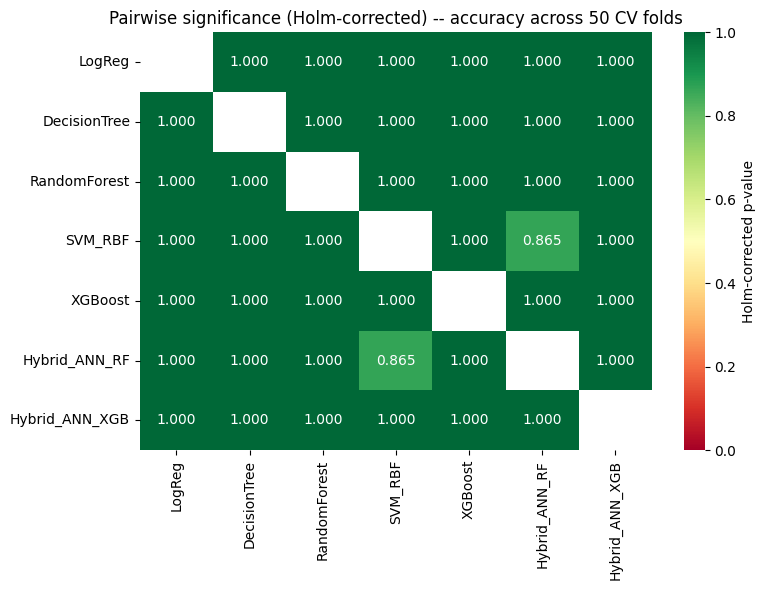

In [9]:
# 5b. Significance matrix heatmap
sig_matrix = pd.DataFrame(np.nan, index=MODEL_NAMES, columns=MODEL_NAMES)
for (a, b), hp in zip(pairs, holm_p):
    sig_matrix.loc[a, b] = hp
    sig_matrix.loc[b, a] = hp

plt.figure(figsize=(8, 6))
sns.heatmap(sig_matrix.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, cbar_kws={'label': 'Holm-corrected p-value'})
plt.title(f'Pairwise significance (Holm-corrected) -- accuracy across {N_SPLITS*N_REPEATS} CV folds')
plt.tight_layout()
plt.show()

In [10]:
# 6. DeLong's test implementation (Sun & Xu, 2014)
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N_ = len(x)
    T = np.zeros(N_, dtype=float)
    i = 0
    while i < N_:
        j = i
        while j < N_ and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N_, dtype=float)
    T2[J] = T
    return T2

def fastDeLong(preds_sorted_by_label, m):
    n = preds_sorted_by_label.shape[1] - m
    k = preds_sorted_by_label.shape[0]
    pos = preds_sorted_by_label[:, :m]
    neg = preds_sorted_by_label[:, m:]
    tx = np.empty([k, m]); ty = np.empty([k, n]); tz = np.empty([k, m+n])
    for r in range(k):
        tx[r, :] = compute_midrank(pos[r, :])
        ty[r, :] = compute_midrank(neg[r, :])
        tz[r, :] = compute_midrank(preds_sorted_by_label[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx, sy = np.cov(v01), np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def delong_roc_test(y_true, prob_a, prob_b):
    order = np.argsort(-y_true)
    y_sorted = y_true[order]
    m = int(np.sum(y_sorted))
    preds = np.vstack([prob_a, prob_b])[:, order]
    aucs, cov = fastDeLong(preds, m)
    diff = aucs[0] - aucs[1]
    var = cov[0,0] + cov[1,1] - 2*cov[0,1]
    if var <= 0:
        return aucs, diff, 1.0
    z = diff / np.sqrt(var)
    p = 2 * stats.norm.sf(np.abs(z))
    return aucs, diff, p

yte = holdout_store['y'].astype(float)
probas = holdout_store['probas']
delong_rows = []
for a, b in itertools.combinations(MODEL_NAMES, 2):
    aucs, diff, p = delong_roc_test(yte, probas[a], probas[b])
    delong_rows.append({'Model A': a, 'Model B': b, 'AUC A': aucs[0], 'AUC B': aucs[1],
                         'AUC diff': diff, 'DeLong p': p})
pd.DataFrame(delong_rows).sort_values('DeLong p')

,Model A,Model B,AUC A,AUC B,AUC diff,DeLong p
10,DecisionTree,Hybrid_ANN_XGB,0.969333,0.999253,-0.029920,0.000614
6,DecisionTree,RandomForest,0.969333,0.999493,-0.030160,0.000624
9,DecisionTree,Hybrid_ANN_RF,0.969333,0.999307,-0.029973,0.000638
8,DecisionTree,XGBoost,0.969333,0.999253,-0.029920,0.000645
0,LogReg,DecisionTree,0.999387,0.969333,0.030053,0.000665
7,DecisionTree,SVM_RBF,0.969333,0.999600,-0.030267,0.000676
12,RandomForest,XGBoost,0.999493,0.999253,0.000240,0.151243
2,LogReg,SVM_RBF,0.999387,0.999600,-0.000213,0.214524
16,SVM_RBF,Hybrid_ANN_RF,0.999600,0.999307,0.000293,0.348308
17,SVM_RBF,Hybrid_ANN_XGB,0.999600,0.999253,0.000347,0.352370


In [11]:
pairs_auc = list(itertools.combinations(MODEL_NAMES, 2))
raw_pa, md_a = [], []
for a, b in pairs_auc:
    d = np.array(fold_metrics[a]['auc']) - np.array(fold_metrics[b]['auc'])
    mdiff, _, p_ = corrected_paired_ttest(d, train_ratio, test_ratio); raw_pa.append(p_); md_a.append(mdiff)
order_a = np.argsort(raw_pa); holm_a = [None] * len(raw_pa)
for rank, i in enumerate(order_a): holm_a[i] = min(raw_pa[i] * (len(raw_pa) - rank), 1.0)
holm_a = np.maximum.accumulate(np.array(holm_a)[order_a])[np.argsort(order_a)]       # enforce monotone Holm

delong_rep = []
for a, b in pairs_auc:
    ps = [delong_roc_test(repeat_y[r].astype(float), repeat_oof[r][a], repeat_oof[r][b])[2] for r in range(N_REPEATS)]
    delong_rep.append((np.median(ps), int(np.sum(np.array(ps) < 0.05))))

auc_sig_df = pd.DataFrame({'Model A': [p[0] for p in pairs_auc], 'Model B': [p[1] for p in pairs_auc],
                           'Mean AUC diff (per-fold)': md_a, 'NB raw p': raw_pa, 'NB Holm p': holm_a,
                           'DeLong median p (over repeats)': [x[0] for x in delong_rep],
                           f'DeLong p<0.05 in x/{N_REPEATS} repeats': [x[1] for x in delong_rep]})
auc_sig_df['NB Holm significant'] = auc_sig_df['NB Holm p'] < 0.05
print(auc_sig_df.sort_values('NB Holm p').head(10).round(5).to_string(index=False))
print(f"\nPairs significant by corrected per-fold AUC test (Holm): {int(auc_sig_df['NB Holm significant'].sum())}/{len(auc_sig_df)}")
print(f"Pairs with DeLong p<0.05 in at least 80% of repeats: {int((auc_sig_df.iloc[:, 6] >= 0.8*N_REPEATS).sum())}/{len(auc_sig_df)}")
auc_sig_df.to_csv('table_auc_significance.csv', index=False)
print("\nJustification text: pooled out-of-fold predictions give every patient one prediction from a model that never saw them, which is what")
print("DeLong's test needs; but the fold-models share training data, so DeLong p-values are anti-conservative. Hence the corrected per-fold test is")
print("primary, and DeLong is reported as secondary and repeated across all repeats to show it is not an artefact of one partition.")

     Model A        Model B  Mean AUC diff (per-fold)  NB raw p  NB Holm p  DeLong median p (over repeats)  DeLong p<0.05 in x/10 repeats  NB Holm significant
      LogReg   DecisionTree                   0.02641   0.00215    0.03603                         0.00256                             10                 True
DecisionTree        SVM_RBF                  -0.02661   0.00208    0.03603                         0.00242                             10                 True
DecisionTree   RandomForest                  -0.02679   0.00181    0.03603                         0.00230                             10                 True
DecisionTree        XGBoost                  -0.02656   0.00172    0.03603                         0.00224                             10                 True
DecisionTree  Hybrid_ANN_RF                  -0.02657   0.00184    0.03603                         0.00217                             10                 True
DecisionTree Hybrid_ANN_XGB                  -

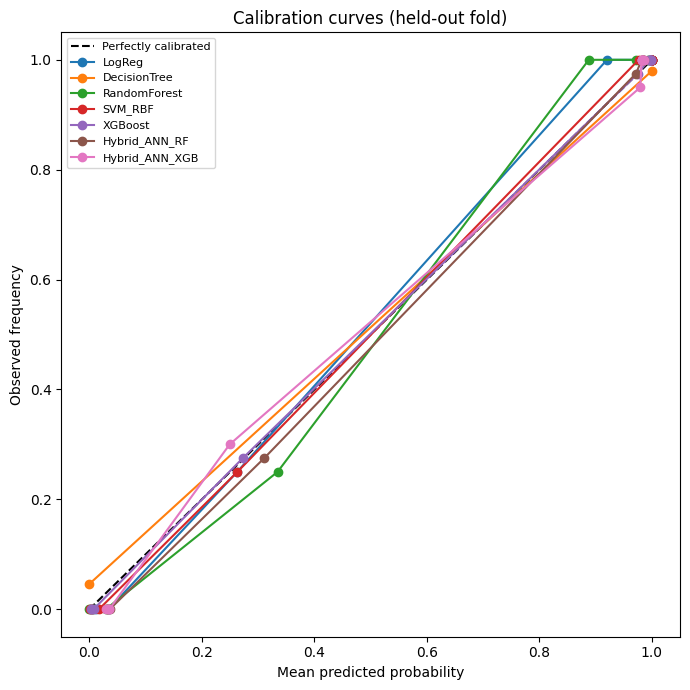

,Model,ECE,Brier (holdout)
4,XGBoost,0.008268,0.010307
3,SVM_RBF,0.019657,0.009222
6,Hybrid_ANN_XGB,0.027345,0.010046
5,Hybrid_ANN_RF,0.027607,0.008957
0,LogReg,0.028658,0.012606
1,DecisionTree,0.030000,0.030000
2,RandomForest,0.031713,0.011684


In [12]:
# 7. Calibration curves + Expected Calibration Error (ECE)
from sklearn.calibration import calibration_curve

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (y_prob > lo) & (y_prob <= hi) if i > 0 else (y_prob >= lo) & (y_prob <= hi)
        if mask.sum() == 0:
            continue
        acc_bin = y_true[mask].mean()
        conf_bin = y_prob[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc_bin - conf_bin)
    return ece

plt.figure(figsize=(7, 7))
plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')
ece_rows = []
for name in MODEL_NAMES:
    frac_pos, mean_pred = calibration_curve(yte, probas[name], n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=name)
    ece = expected_calibration_error(yte, probas[name])
    brier = brier_score_loss(yte, probas[name])
    ece_rows.append({'Model': name, 'ECE': ece, 'Brier (holdout)': brier})
plt.xlabel('Mean predicted probability'); plt.ylabel('Observed frequency')
plt.title('Calibration curves (held-out fold)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(ece_rows).sort_values('ECE')

In [13]:
# 8. Binomial CI width for reported literature accuracies at n_test ~ 80 (Wilson interval)
# NOTE: n_test = 80 is an ASSUMPTION (typical 80/20 split of 400 records) - verify each paper's actual test size,
# verify every accuracy below against the original paper, and add these papers to the bibliography.
from statsmodels.stats.proportion import proportion_confint
literature_claims = {
    'Pal 2022 - DT':            0.9592,
    'Pal 2022 - DT+Bagging':    0.9723,
    'Almustafa 2021 - J48/DT':  0.99,
    'Ensemble paper - RSE':     1.00,
}
n_test = 80
def lit_ci(acc, n=n_test):
    lo, hi = proportion_confint(int(round(acc*n)), n, alpha=0.05, method='wilson')
    return lo, hi
rows = []
for label, acc in literature_claims.items():
    lo, hi = lit_ci(acc)
    rows.append({'Reported claim': label, 'Accuracy': acc,
                 '95% CI (Wilson)': f'[{lo*100:.2f}%, {hi*100:.2f}%]',
                 'CI half-width (pp)': (hi-lo)/2*100})
lit_ci_df = pd.DataFrame(rows)
lit_ci_df

,Reported claim,Accuracy,95% CI (Wilson),CI half-width (pp)
0,Pal 2022 - DT,0.9592,"[89.55%, 98.72%]",4.585632
1,Pal 2022 - DT+Bagging,0.9723,"[91.34%, 99.31%]",3.988072
2,Almustafa 2021 - J48/DT,0.9900,"[93.25%, 99.78%]",3.262636
3,Ensemble paper - RSE,1.0000,"[95.42%, 100.00%]",2.290906


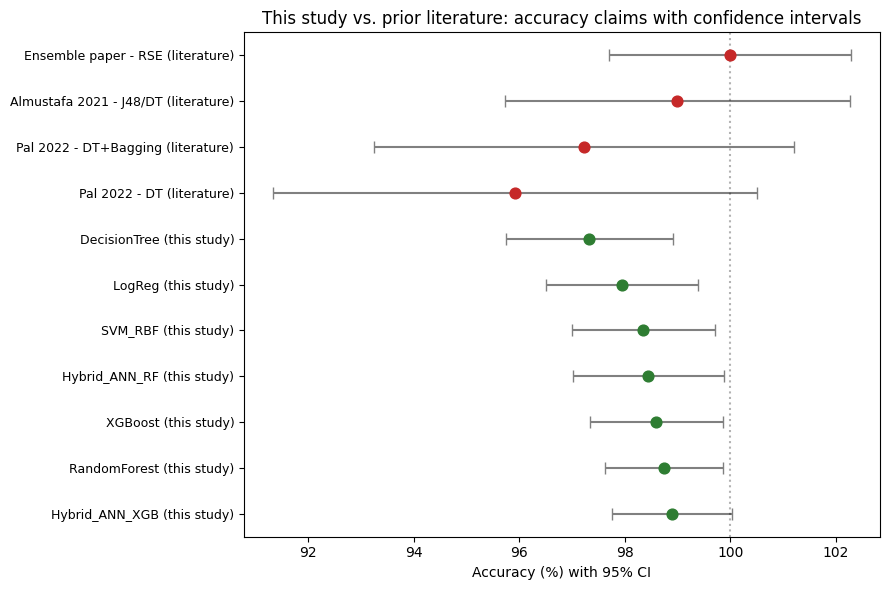

In [14]:
# 9. Combined CI comparison plot: your models vs. literature claims
fig, ax = plt.subplots(figsize=(9, 6))

y_pos = 0
labels, centers, errs, colors = [], [], [], []
for _, row in results_df.iterrows():
    n_folds = len(fold_metrics[row['Model']]['acc'])
    acc_arr = np.array(fold_metrics[row['Model']]['acc'])
    ci = nb_ci_halfwidth(acc_arr)          # Nadeau-Bengio-corrected CI
    labels.append(f"{row['Model']} (this study)")
    centers.append(row['Acc mean']*100)
    errs.append(ci*100)
    colors.append('#2E7D32')

for label, acc in literature_claims.items():
    lo, hi = lit_ci(acc)
    labels.append(f'{label} (literature)')
    centers.append(acc*100)
    errs.append((hi-lo)/2*100)
    colors.append('#C62828')

y_positions = np.arange(len(labels))
ax.errorbar(centers, y_positions, xerr=errs, fmt='o', capsize=4, color='gray', ecolor='gray')
for yp, c, col in zip(y_positions, centers, colors):
    ax.scatter(c, yp, color=col, s=60, zorder=3)
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Accuracy (%) with 95% CI')
ax.set_title('This study vs. prior literature: accuracy claims with confidence intervals')
ax.axvline(x=max(c for c in centers), color='black', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Extra published-style baselines and class-weighted variants (Reviewer 3: comparison with existing methods, class imbalance)
Uses the identical 50 folds as the main zoo, so comparisons are paired. About 10 minutes.

In [15]:
# R3-1 / R3-2: extra published-style baselines + class-weighted variants on the SAME 50 folds as cell 3
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from scipy import stats as _st

RUN_ANN = True                       # set False to skip the stand-alone ANN (saves ~3-5 min)
X_all = df.drop(columns='Class').values; y_all = df['Class'].values
spw = (y_all == 0).sum() / (y_all == 1).sum()          # 0.6 = n_neg / n_pos

EXTRA_FACTORY = {
 'KNN':                    lambda: KNeighborsClassifier(n_neighbors=5),
 'NaiveBayes':             lambda: GaussianNB(),
 'AdaBoost':               lambda: AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
 'GradBoost':              lambda: GradientBoostingClassifier(random_state=RANDOM_STATE),
 'ExtraTrees':             lambda: ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
 'SoftVote_LR_RF_SVM_XGB': lambda: VotingClassifier([('lr', BASE_MODEL_FACTORY['LogReg']()), ('rf', BASE_MODEL_FACTORY['RandomForest']()),
                                                    ('svm', BASE_MODEL_FACTORY['SVM_RBF']()), ('xgb', BASE_MODEL_FACTORY['XGBoost']())], voting='soft'),
 # class-weighted variants (imbalance sensitivity)
 'LogReg_balanced':        lambda: LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
 'RandomForest_balanced':  lambda: RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
 'XGBoost_weighted':       lambda: XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
                                                 scale_pos_weight=spw, eval_metric='logloss', random_state=RANDOM_STATE),
}
names6 = list(EXTRA_FACTORY) + (['ANN_alone'] if RUN_ANN else [])
ext_oof = {r: {n: [] for n in names6} for r in range(N_REPEATS)}
ext_acc = {n: [] for n in names6}; ext_auc = {n: [] for n in names6}

for repeat in range(N_REPEATS):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + repeat)   # identical to cell '# 3'
    yt_all = []
    for tr, te in skf.split(X_all, y_all):
        sc = StandardScaler(); Xtr = sc.fit_transform(X_all[tr]); Xte = sc.transform(X_all[te])
        ytr, yte = y_all[tr], y_all[te]
        for n, fac in EXTRA_FACTORY.items():
            m = fac(); m.fit(Xtr, ytr); p = m.predict_proba(Xte)[:, 1]
            ext_oof[repeat][n].append(p); ext_acc[n].append(accuracy_score(yte, (p >= .5).astype(int))); ext_auc[n].append(roc_auc_score(yte, p))
        if RUN_ANN:
            p = fit_ann_fast(Xtr, ytr, epochs=FAST_ANN_EPOCHS*2, patience=15).predict(Xte, verbose=0).flatten()
            ext_oof[repeat]['ANN_alone'].append(p); ext_acc['ANN_alone'].append(accuracy_score(yte, (p >= .5).astype(int))); ext_auc['ANN_alone'].append(roc_auc_score(yte, p))
        yt_all.append(yte)
    for n in names6: ext_oof[repeat][n] = np.concatenate(ext_oof[repeat][n])
    if 'repeat_y' in globals(): assert np.array_equal(np.concatenate(yt_all), repeat_y[repeat]), "fold order differs from cell '# 3'"
    print(f"Repeat {repeat+1}/{N_REPEATS} done")

def _nb(d, tr_=0.8, te_=0.2):
    n = len(d); v = np.var(d, ddof=1) * (1/n + te_/tr_)
    return (np.mean(d), 2*_st.t.sf(abs(np.mean(d)/np.sqrt(v)), n-1)) if v > 0 else (0.0, 1.0)

ref = 'Hybrid_ANN_XGB'
rows = []
for n in names6:
    r = {'Model': n, 'Acc %': 100*np.mean(ext_acc[n]), 'AUC': np.mean(ext_auc[n])}
    if 'fold_metrics' in globals():
        d, p = _nb(np.array(ext_acc[n]) - np.array(fold_metrics[ref]['acc'])); r.update({f'Acc diff vs {ref} (pp)': 100*d, 'raw p': p})
    rows.append(r)
tab6 = pd.DataFrame(rows)
if 'raw p' in tab6:                                          # Holm correction across these comparisons
    o = np.argsort(tab6['raw p'].values); m_ = len(o); h = np.zeros(m_)
    for rank, i in enumerate(o): h[i] = min(1.0, tab6['raw p'].values[i] * (m_ - rank))
    tab6['Holm p'] = np.maximum.accumulate(h[o])[np.argsort(o)]
print(tab6.round(4).to_string(index=False))

Repeat 1/10 done
Repeat 2/10 done
Repeat 3/10 done
Repeat 4/10 done
Repeat 5/10 done
Repeat 6/10 done
Repeat 7/10 done
Repeat 8/10 done
Repeat 9/10 done
Repeat 10/10 done
                 Model  Acc %    AUC  Acc diff vs Hybrid_ANN_XGB (pp)  raw p  Holm p
                   KNN 97.575 0.9959                           -1.325 0.0869  0.7823
            NaiveBayes 91.000 0.9937                           -7.900 0.0000  0.0002
              AdaBoost 98.150 0.9991                           -0.750 0.2073  1.0000
             GradBoost 98.650 0.9997                           -0.250 0.6990  1.0000
            ExtraTrees 99.200 0.9999                            0.300 0.6990  1.0000
SoftVote_LR_RF_SVM_XGB 99.300 0.9998                            0.400 0.3917  1.0000
       LogReg_balanced 97.925 0.9994                           -0.975 0.1459  1.0000
 RandomForest_balanced 98.950 0.9999                            0.050 0.9383  1.0000
      XGBoost_weighted 98.700 0.9996                           -

## 4. Leakage audit (original heuristic) and feature-set ablation V1-V5

In [16]:
# 10. Leakage audit -- detect mean-imputation artifacts and test their predictive power alone
print("Top repeated value per column (candidate mean-imputation constants):")
for col in df.drop(columns='Class').columns:
    vc = df[col].value_counts()
    top_val, top_count = vc.index[0], vc.iloc[0]
    print(f"  {col:6s}: {top_val:>10} appears {top_count:3d}/{len(df)} times ({top_count/len(df)*100:5.1f}%)")

Top repeated value per column (candidate mean-imputation constants):
  Bp    :       80.0 appears 116/400 times ( 29.0%)
  Sg    :       1.02 appears 153/400 times ( 38.2%)
  Al    :        0.0 appears 199/400 times ( 49.8%)
  Su    :        0.0 appears 339/400 times ( 84.8%)
  Rbc   :        1.0 appears 353/400 times ( 88.2%)
  Bu    :       57.0 appears  20/400 times (  5.0%)
  Sc    :        1.2 appears  40/400 times ( 10.0%)
  Sod   :     137.53 appears  87/400 times ( 21.8%)
  Pot   :       4.63 appears  88/400 times ( 22.0%)
  Hemo  :      12.53 appears  52/400 times ( 13.0%)
  Wbcc  :     8406.0 appears 106/400 times ( 26.5%)
  Rbcc  :       4.71 appears 131/400 times ( 32.8%)
  Htn   :        0.0 appears 251/400 times ( 62.7%)


In [17]:
# 11. Confirm leakage: does being "imputed" correlate with the label?
suspect_cols = {'Sod': 137.53, 'Pot': 4.63, 'Hemo': 12.53, 'Wbcc': 8406.0, 'Rbcc': 4.71}

leak_rows = []
for col, val in suspect_cols.items():
    flag = np.isclose(df[col], val)
    leak_rows.append({
        'Column': col,
        'N imputed': flag.sum(),
        'CKD rate | imputed': df.loc[flag, 'Class'].mean(),
        'CKD rate | not imputed': df.loc[~flag, 'Class'].mean(),
    })
leak_df = pd.DataFrame(leak_rows)
print(leak_df)
print(f"\nOverall CKD rate: {df['Class'].mean():.4f}")

  Column  N imputed  CKD rate | imputed  CKD rate | not imputed
0    Sod         87            0.942529                0.536741
1    Pot         88            0.943182                0.535256
2   Hemo         52            0.884615                0.586207
3   Wbcc        106            0.933962                0.513605
4   Rbcc        131            0.946565                0.468401

Overall CKD rate: 0.6250


In [18]:
# 12. Missingness-only model: train using ONLY missingness flags (no real clinical values)
X_missing_only = pd.DataFrame({c: np.isclose(df[c], v).astype(int) for c, v in suspect_cols.items()})
y = df['Class']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
clf = LogisticRegression()
acc_scores = cross_val_score(clf, X_missing_only, y, cv=cv, scoring='accuracy')
auc_scores = cross_val_score(clf, X_missing_only, y, cv=cv, scoring='roc_auc')

print(f"Missingness-only model -- Accuracy: {acc_scores.mean():.4f} +/- {acc_scores.std():.4f}")
print(f"Missingness-only model -- AUC:      {auc_scores.mean():.4f} +/- {auc_scores.std():.4f}")
print(f"Rows with at least one imputed value: {(X_missing_only.sum(axis=1) > 0).sum()} / {len(df)}")

Missingness-only model -- Accuracy: 0.7225 +/- 0.0289
Missingness-only model -- AUC:      0.7658 +/- 0.0238
Rows with at least one imputed value: 166 / 400


In [19]:
# 13. Build 5 feature-set variants to isolate the leakage effect
leak_cols = list(suspect_cols.keys())
X_base = df.drop(columns='Class').copy()

X_v1_baseline = X_base.copy()  # what every published paper uses

X_v2_with_flags = X_base.copy()  # baseline + explicit "was imputed" flags
for col, val in suspect_cols.items():
    X_v2_with_flags[f'{col}_was_imputed'] = np.isclose(X_base[col], val).astype(int)

X_v3_knn = X_base.copy()  # constants -> NaN -> KNN re-imputed
for col, val in suspect_cols.items():
    X_v3_knn.loc[np.isclose(X_v3_knn[col], val), col] = np.nan
knn_imputer = KNNImputer(n_neighbors=5)
X_v3_knn = pd.DataFrame(knn_imputer.fit_transform(X_v3_knn), columns=X_v3_knn.columns, index=X_v3_knn.index)

X_v4_no_leak_cols = X_base.drop(columns=leak_cols)  # drop the 5 leak-prone columns entirely

X_v5_floor_plus_flags = X_v4_no_leak_cols.copy()  # clean floor + flags, no raw leaky values
for col, val in suspect_cols.items():
    X_v5_floor_plus_flags[f'{col}_was_imputed'] = np.isclose(X_base[col], val).astype(int)

print("Variant shapes:")
for name, Xv in [('V1 baseline', X_v1_baseline), ('V2 with flags', X_v2_with_flags),
                  ('V3 KNN re-imputed', X_v3_knn), ('V4 no-leak floor', X_v4_no_leak_cols),
                  ('V5 floor + flags', X_v5_floor_plus_flags)]:
    print(f"  {name:20s}: {Xv.shape}")

Variant shapes:
  V1 baseline         : (400, 13)
  V2 with flags       : (400, 18)
  V3 KNN re-imputed   : (400, 13)
  V4 no-leak floor    : (400, 8)
  V5 floor + flags    : (400, 13)


In [20]:
# 14. Evaluate each variant with repeated CV
def evaluate_variant(X, y, model_name='XGBoost', n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE):
    rcv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    accs, aucs = [], []
    factory = BASE_MODEL_FACTORY[model_name]
    Xv = X.values if hasattr(X, 'values') else X
    yv = y.values if hasattr(y, 'values') else y
    for tr_idx, te_idx in rcv.split(Xv, yv):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xv[tr_idx])
        Xte = scaler.transform(Xv[te_idx])
        m = factory()
        m.fit(Xtr, yv[tr_idx])
        pred = m.predict(Xte)
        proba = m.predict_proba(Xte)[:, 1]
        accs.append(accuracy_score(yv[te_idx], pred))
        aucs.append(roc_auc_score(yv[te_idx], proba))
    return np.array(accs), np.array(aucs)

variants = {
    'V1 Baseline (current papers)': X_v1_baseline,
    'V2 Transparent (+flags)':      X_v2_with_flags,
    'V3 KNN re-imputed':            X_v3_knn,
    'V4 No-leak floor':             X_v4_no_leak_cols,
    'V5 Floor + flags only':        X_v5_floor_plus_flags,
}

variant_results = {}
for name, Xv in variants.items():
    accs, aucs = evaluate_variant(Xv, y, model_name='XGBoost')
    variant_results[name] = {'acc': accs, 'auc': aucs}
    print(f"{name:32s} | Acc: {accs.mean():.4f} +/- {accs.std():.4f} | AUC: {aucs.mean():.4f} +/- {aucs.std():.4f}")

V1 Baseline (current papers)     | Acc: 0.9875 +/- 0.0100 | AUC: 0.9996 +/- 0.0007
V2 Transparent (+flags)          | Acc: 0.9892 +/- 0.0103 | AUC: 0.9997 +/- 0.0006
V3 KNN re-imputed                | Acc: 0.9855 +/- 0.0121 | AUC: 0.9993 +/- 0.0010
V4 No-leak floor                 | Acc: 0.9708 +/- 0.0163 | AUC: 0.9970 +/- 0.0029
V5 Floor + flags only            | Acc: 0.9800 +/- 0.0164 | AUC: 0.9988 +/- 0.0015


In [21]:
# 15. Significance tests between variants (reuses Nadeau-Bengio corrected t-test)
for pair_a, pair_b in [('V1 Baseline (current papers)', 'V4 No-leak floor'),
                       ('V1 Baseline (current papers)', 'V5 Floor + flags only')]:
    diffs = variant_results[pair_a]['acc'] - variant_results[pair_b]['acc']
    mean_diff, t_stat, p = corrected_paired_ttest(diffs, train_ratio, test_ratio)
    print(f"{pair_a} vs {pair_b} -- mean diff: {mean_diff*100:.2f} pp | t={t_stat:.3f} | p={p:.5f}")

V1 Baseline (current papers) vs V4 No-leak floor -- mean diff: 1.68 pp | t=1.850 | p=0.07036
V1 Baseline (current papers) vs V5 Floor + flags only -- mean diff: 0.75 pp | t=0.816 | p=0.41817


In [22]:
# 16. Tighten V1 vs V4 estimate with 10 repeats for the final paper numbers
accs1_tight, aucs1_tight = evaluate_variant(X_v1_baseline, y, model_name='XGBoost', n_repeats=N_REPEATS)
accs4_tight, aucs4_tight = evaluate_variant(X_v4_no_leak_cols, y, model_name='XGBoost', n_repeats=N_REPEATS)
print(f"V1 (10 repeats) | Acc: {accs1_tight.mean():.4f} +/- {accs1_tight.std():.4f}")
print(f"V4 (10 repeats) | Acc: {accs4_tight.mean():.4f} +/- {accs4_tight.std():.4f}")

diffs_tight = accs1_tight - accs4_tight
mean_diff, t_stat, p = corrected_paired_ttest(diffs_tight, train_ratio=(N_SPLITS-1)/N_SPLITS, test_ratio=1/N_SPLITS)
print(f"V1 vs V4 (10 repeats) -- mean diff: {mean_diff*100:.2f} pp | t={t_stat:.3f} | p={p:.5f}")
p_v1v4, diff_v1v4_pp = p, mean_diff*100     # saved for the summary cells

V1 (10 repeats) | Acc: 0.9875 +/- 0.0100
V4 (10 repeats) | Acc: 0.9708 +/- 0.0163
V1 vs V4 (10 repeats) -- mean diff: 1.68 pp | t=1.850 | p=0.07036


## 5. Ground-truth missingness audit and in-fold imputation (Reviewers 1 and 2)
**Check the alignment output first.** If it raises an error, the rows do not match the raw UCI file - do not use the masks.
The audit table may show more imputed columns than the original five-column list; if so, the leakage numbers in the abstract must be rewritten.

In [23]:
# R2-1: Ground-truth missingness audit using the ORIGINAL UCI CKD file (label-free)
from ucimlrepo import fetch_ucirepo
from scipy.stats import fisher_exact
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

raw = fetch_ucirepo(id=336)                      # original 400 x 24 UCI CKD file (with true NaNs)
raw_X = raw.data.features.copy()
raw_X.columns = [c.strip().lower() for c in raw_X.columns]
for c in raw_X.columns:                          # normalise '?' / blanks to NaN
    if raw_X[c].dtype == object:
        raw_X[c] = raw_X[c].astype(str).str.strip().replace({'?': np.nan, '': np.nan, 'nan': np.nan, 'None': np.nan})

col_map_raw = {'Bp':'bp','Sg':'sg','Al':'al','Su':'su','Rbc':'rbc','Bu':'bu','Sc':'sc',
               'Sod':'sod','Pot':'pot','Hemo':'hemo','Wbcc':'wbcc','Rbcc':'rbcc','Htn':'htn'}
feat_cols = list(col_map_raw.keys())
y = df['Class']
assert len(raw_X) == len(df), f"Row count differs: raw={len(raw_X)} csv={len(df)}"

# (a) Alignment check: CSV must equal the raw file wherever the raw value was actually observed
num_cols = ['Bp','Sg','Al','Su','Bu','Sc','Sod','Pot','Hemo','Wbcc','Rbcc']
print("Alignment check (CSV == raw on observed rows):")
align = []
for c in num_cols:
    r = pd.to_numeric(raw_X[col_map_raw[c]], errors='coerce'); obs = r.notna()
    m = np.isclose(df.loc[obs, c], r[obs], rtol=1e-3, atol=1e-6).mean(); align.append(m)
    print(f"  {c:5s} observed={obs.sum():3d}  match={m*100:5.1f}%")
if min(align) < 0.95:
    raise RuntimeError("Rows do not align with the raw file (match < 95%). Do NOT trust the masks below.")

# (b) True missingness mask (label-free) + per-column audit
miss = pd.DataFrame({c: raw_X[col_map_raw[c]].isna().values for c in feat_cols}, index=df.index)
suspect_cols_orig = ['Sod','Pot','Hemo','Wbcc','Rbcc']        # the 5 columns found by the modal-value heuristic
rows = []
for c in feat_cols:
    m = miss[c].values
    k = int(m.sum())
    const = df.loc[m, c].mode().iloc[0] if k else np.nan
    ck_m = y[m].mean() if k else np.nan
    ck_o = y[~m].mean()
    p = np.nan
    if 0 < k < len(df):
        p = fisher_exact([[int(y[m].sum()), int((1-y[m]).sum())],
                          [int(y[~m].sum()), int((1-y[~m]).sum())]])[1]
    rows.append({'Column': c, 'N missing in raw': k, '% missing': round(100*k/len(df),1),
                 'Value filled in CSV': const, 'CKD rate | missing': ck_m, 'CKD rate | observed': ck_o,
                 'Fisher p': p, 'In original 5-col list': c in suspect_cols_orig})
audit_df = pd.DataFrame(rows).sort_values('N missing in raw', ascending=False).reset_index(drop=True)
print("\nGround-truth missingness audit (all 13 features):")
print(audit_df.to_string(index=False))
print(f"\nRows with >=1 truly missing value among the 13 features: {(miss.sum(axis=1) > 0).sum()} / {len(df)}")

# (c) Missingness-only model using ALL 13 true flags vs the original 5
rcv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)
for label, cols in [('Original 5 columns', suspect_cols_orig), ('All 13 columns', feat_cols)]:
    Xf = miss[cols].astype(int).values
    a = cross_val_score(LogisticRegression(max_iter=1000), Xf, y, cv=rcv, scoring='accuracy')
    u = cross_val_score(LogisticRegression(max_iter=1000), Xf, y, cv=rcv, scoring='roc_auc')
    print(f"Missingness-only LR, {label:20s} Acc {a.mean():.4f} | AUC {u.mean():.4f}   (majority baseline {max(y.mean(),1-y.mean()):.4f})")

# (d) Observed-only version of the features (imputed cells -> NaN); used by NEW-2 and NEW-4
df_nan = df[feat_cols].mask(miss)
print("\nNaN cells restored:", int(df_nan.isna().sum().sum()))

Alignment check (CSV == raw on observed rows):
  Bp    observed=388  match=100.0%
  Sg    observed=353  match=100.0%
  Al    observed=354  match=100.0%
  Su    observed=351  match=100.0%
  Bu    observed=381  match=100.0%
  Sc    observed=383  match=100.0%
  Sod   observed=313  match=100.0%
  Pot   observed=312  match=100.0%
  Hemo  observed=348  match=100.0%
  Wbcc  observed=294  match=100.0%
  Rbcc  observed=269  match=100.0%

Ground-truth missingness audit (all 13 features):
Column  N missing in raw  % missing  Value filled in CSV  CKD rate | missing  CKD rate | observed     Fisher p  In original 5-col list
   Rbc               152       38.0                 1.00            0.940789             0.431452 6.957720e-28                   False
  Rbcc               131       32.8                 4.71            0.946565             0.468401 1.546211e-23                    True
  Wbcc               106       26.5              8406.00            0.933962             0.513605 1.449937e-16  

In [24]:
# R1-2 / R2-2: every preprocessing step INSIDE each fold (true NaNs restored, in-fold imputation)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier
from scipy import stats

def make_xgb():
    return XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.9,
                         colsample_bytree=0.9, eval_metric='logloss', random_state=42)

def eval_pipeline(X, y, make_pipe, n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=42):
    rcv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)  # same folds for every variant
    Xv, yv = X.values.astype(float), np.asarray(y)
    accs, aucs = [], []
    for tr, te in rcv.split(Xv, yv):
        pipe = make_pipe(); pipe.fit(Xv[tr], yv[tr])
        pr = pipe.predict_proba(Xv[te])[:, 1]
        accs.append(accuracy_score(yv[te], (pr >= 0.5).astype(int))); aucs.append(roc_auc_score(yv[te], pr))
    return np.array(accs), np.array(aucs)

def nb_test(diffs, train_ratio=0.8, test_ratio=0.2):          # Nadeau-Bengio corrected paired t-test
    n = len(diffs); v = np.var(diffs, ddof=1) * (1/n + test_ratio/train_ratio)
    t = np.mean(diffs) / np.sqrt(v) if v > 0 else np.nan
    return np.mean(diffs), t, (2*stats.t.sf(abs(t), n-1) if v > 0 else 1.0)

miss_rate = miss.mean()
heavy = [c for c in df_nan.columns if miss_rate[c] > 0.10]    # pre-specified rule: >10% truly missing (label never used)
print("Columns with >10% true missingness (dropped in W3):", heavy)

w_variants = {
 'W0 Pre-imputed CSV (as in paper)':        (df[feat_cols],            lambda: Pipeline([('sc', StandardScaler()), ('m', make_xgb())])),
 'W1 NaN + in-fold median imputation':      (df_nan,                   lambda: Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler()), ('m', make_xgb())])),
 'W2 W1 + in-fold missing indicators':      (df_nan,                   lambda: Pipeline([('imp', SimpleImputer(strategy='median', add_indicator=True)), ('sc', StandardScaler()), ('m', make_xgb())])),
 'W3 W1 without the >10%-missing columns':  (df_nan.drop(columns=heavy), lambda: Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler()), ('m', make_xgb())])),
}
res_w = {}
for name, (Xv, mk) in w_variants.items():
    a, u = eval_pipeline(Xv, y, mk); res_w[name] = (a, u)
    print(f"{name:42s} | features={Xv.shape[1]:2d} | Acc {a.mean():.4f} +/- {a.std():.4f} | AUC {u.mean():.4f}")

print("\nNadeau-Bengio corrected paired tests (accuracy):")
w_names = list(res_w)
for a_, b_ in [(w_names[0], w_names[1]), (w_names[1], w_names[2]), (w_names[1], w_names[3]), (w_names[0], w_names[3])]:
    d, t, p = nb_test(res_w[a_][0] - res_w[b_][0])
    print(f"  {a_[:2]} vs {b_[:2]}: mean diff {d*100:+.2f} pp | t={t:.3f} | p={p:.4f}")

Columns with >10% true missingness (dropped in W3): ['Sg', 'Al', 'Su', 'Rbc', 'Sod', 'Pot', 'Hemo', 'Wbcc', 'Rbcc']
W0 Pre-imputed CSV (as in paper)           | features=13 | Acc 0.9875 +/- 0.0100 | AUC 0.9996
W1 NaN + in-fold median imputation         | features=13 | Acc 0.9885 +/- 0.0114 | AUC 0.9995
W2 W1 + in-fold missing indicators         | features=13 | Acc 0.9917 +/- 0.0102 | AUC 0.9999
W3 W1 without the >10%-missing columns     | features= 4 | Acc 0.8943 +/- 0.0196 | AUC 0.9597

Nadeau-Bengio corrected paired tests (accuracy):
  W0 vs W1: mean diff -0.10 pp | t=-0.389 | p=0.6990
  W1 vs W2: mean diff -0.32 pp | t=-0.886 | p=0.3798
  W1 vs W3: mean diff +9.42 pp | t=8.827 | p=0.0000
  W0 vs W3: mean diff +9.33 pp | t=9.235 | p=0.0000


## 6. External validation on UCI #857

In [25]:
# 17. Fetch external dataset
from ucimlrepo import fetch_ucirepo
risk_ckd = fetch_ucirepo(id=857)
X_external = risk_ckd.data.features
y_external = risk_ckd.data.targets
print("External shape:", X_external.shape)
print(X_external.columns.tolist())

External shape: (200, 28)
['bp (Diastolic)', 'bp limit', 'sg', 'al', 'rbc', 'su', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sod', 'sc', 'pot', 'hemo', 'pcv', 'rbcc', 'wbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'grf', 'stage', 'affected', 'age']


In [26]:
# === Bin-to-numeric alignment for external dataset (UCI #857) ===
import re

def parse_bin_to_midpoint(val):
    """Convert 'X - Y' -> midpoint, '< X' -> X, '>= X' -> X. Returns np.nan if unparseable."""
    val = str(val).strip()
    if val.startswith('<'):
        num = re.findall(r'[\d.]+', val)
        return float(num[0]) if num else np.nan
    if val.startswith('≥') or val.startswith('>='):
        num = re.findall(r'[\d.]+', val)
        return float(num[0]) if num else np.nan
    m = re.match(r'([\d.]+)\s*-\s*([\d.]+)', val)
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2
    return np.nan

# Clean numeric-bin columns -> midpoint conversion
numeric_bin_cols = ['sg', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'rbcc', 'wbcc', 'age']
X_external_aligned = X_external.copy()
for col in numeric_bin_cols:
    X_external_aligned[col] = X_external_aligned[col].apply(parse_bin_to_midpoint)

# al / su: Excel-corrupted -> map to ORDINAL RANK, not reconstructed numeric values (documented limitation)
al_order = ['< 0', '1-Jan', '2-Feb', '3-Mar', '≥ 4']
su_order = ['< 0', '2-Jan', '2-Feb', '4-Mar', '4-Apr', '≥ 4']

al_map = {v: i for i, v in enumerate(al_order)}
su_map = {v: i for i, v in enumerate(su_order)}

print("al values not in expected set:", set(X_external['al'].unique()) - set(al_order))
print("su values not in expected set:", set(X_external['su'].unique()) - set(su_order))

X_external_aligned['al'] = X_external['al'].map(al_map)
X_external_aligned['su'] = X_external['su'].map(su_map)

# Sanity check: confirm no NaNs introduced by parsing failures
print("\nNaN counts after alignment:")
print(X_external_aligned[numeric_bin_cols + ['al', 'su']].isna().sum())

X_external_aligned[numeric_bin_cols + ['al', 'su']].describe()

al values not in expected set: set()
su values not in expected set: set()

NaN counts after alignment:
sg      0
bu      0
sc      0
sod     0
pot     0
hemo    0
pcv     0
rbcc    0
wbcc    0
age     4
al      0
su      0
dtype: int64


,sg,bu,sc,sod,pot,hemo,pcv,rbcc,wbcc,age,al,su
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,196.000000,200.000000,200.000000
mean,1.017450,73.150750,4.610750,137.387500,7.662800,12.206750,37.751000,4.732875,8746.35000,53.964286,0.980000,0.385000
std,0.004835,45.857702,2.871741,6.377457,3.413395,2.689822,7.725564,0.849932,2794.68954,15.053452,1.329828,1.015842
min,1.007000,48.100000,3.650000,118.000000,7.310000,6.100000,17.900000,2.690000,4980.00000,12.000000,0.000000,0.000000
25%,1.016000,48.100000,3.650000,135.500000,7.310000,10.650000,31.550000,4.165000,6170.00000,47.000000,0.000000,0.000000
50%,1.020000,48.100000,3.650000,135.500000,7.310000,11.950000,39.350000,4.755000,8550.00000,55.000000,0.000000,0.000000
75%,1.020000,67.150000,3.650000,140.500000,7.310000,14.550000,43.250000,5.345000,8550.00000,62.500000,2.000000,0.000000
max,1.023000,352.900000,28.850000,158.000000,42.590000,16.500000,49.100000,7.410000,24020.00000,74.000000,4.000000,5.000000


In [27]:
# === Patch the one corrupted age bin ===
age_fix = {'20-Dec': (12 + 20) / 2}  # "12-20" -> Excel-corrupted to "20-Dec"
X_external_aligned['age'] = X_external['age'].replace(age_fix).apply(
    lambda v: parse_bin_to_midpoint(v) if isinstance(v, str) else v
)

print("age NaN count after fix:", X_external_aligned['age'].isna().sum())
X_external_aligned['age'].describe()

age NaN count after fix: 0


,age
count,200.000000
mean,53.205000
std,15.825381
min,12.000000
25%,47.000000
50%,55.000000
75%,62.500000
max,74.000000


In [28]:
# === Final alignment: match schema between new_model.csv and external dataset ===

# Column mapping: new_model.csv name -> external aligned name
# Bp is dropped (external's 'bp (Diastolic)' is a different, binary measurement - not comparable)
col_map = {
    'Sg':   'sg',
    'Al':   'al',
    'Su':   'su',
    'Rbc':  'rbc',
    'Bu':   'bu',
    'Sc':   'sc',
    'Sod':  'sod',
    'Pot':  'pot',
    'Hemo': 'hemo',
    'Wbcc': 'wbcc',
    'Rbcc': 'rbcc',
    'Htn':  'htn',
}
shared_train_cols = list(col_map.keys())          # columns as named in new_model.csv
shared_external_cols = list(col_map.values())     # matching columns in external set

# Build matching matrices
X_train_shared = df[shared_train_cols].copy()
y_train_shared = df['Class'].values

X_ext_shared = X_external_aligned[shared_external_cols].copy()
X_ext_shared.columns = shared_train_cols  # rename to match training schema exactly
y_ext_shared = (risk_ckd.data.targets.iloc[:, 0] == 'ckd').astype(int).values

print("Training feature matrix:", X_train_shared.shape)
print("External feature matrix:", X_ext_shared.shape)
print("\nExternal class balance:", pd.Series(y_ext_shared).value_counts(normalize=True).to_dict())

# Sanity check ranges line up roughly (catches unit mismatches before modeling)
comparison = pd.DataFrame({
    'Train mean': X_train_shared.mean(),
    'Train std':  X_train_shared.std(),
    'External mean': X_ext_shared.mean(),
    'External std':  X_ext_shared.std(),
})
comparison

Training feature matrix: (400, 12)
External feature matrix: (200, 12)

External class balance: {1: 0.64, 0: 0.36}


,Train mean,Train std,External mean,External std
Sg,1.017712,0.005434,1.017450,0.004835
Al,1.015000,1.272329,0.980000,1.329828
Su,0.395000,1.040038,0.385000,1.015842
Rbc,0.882500,0.322418,0.125000,0.331549
Bu,57.405500,49.285970,73.150750,45.857702
Sc,3.072350,5.617490,4.610750,2.871741
Sod,137.529025,9.204273,137.387500,6.377457
Pot,4.627850,2.819783,7.662800,3.413395
Hemo,12.526900,2.716171,12.206750,2.689822
Wbcc,8406.090000,2523.219976,8746.350000,2794.689540


In [29]:
# In-dataset reference for the 12 shared features (same protocol as the main zoo)
accs_reduced, aucs_reduced = evaluate_variant(X_train_shared, y_train_shared, model_name='XGBoost', n_repeats=N_REPEATS)
print(f"In-dataset (12 shared features, {N_REPEATS}-repeat CV) | Acc: {accs_reduced.mean():.4f} +/- {accs_reduced.std():.4f}")

In-dataset (12 shared features, 10-repeat CV) | Acc: 0.9875 +/- 0.0100


In [30]:
# === Train final model on ALL of new_model.csv (shared features), test on external set ===
scaler_ext = StandardScaler()
X_train_scaled = scaler_ext.fit_transform(X_train_shared.values)
X_ext_scaled = scaler_ext.transform(X_ext_shared.values)

final_model = BASE_MODEL_FACTORY['XGBoost']()
final_model.fit(X_train_scaled, y_train_shared)

ext_pred = final_model.predict(X_ext_scaled)
ext_proba = final_model.predict_proba(X_ext_scaled)[:, 1]

ext_acc = accuracy_score(y_ext_shared, ext_pred)
ext_auc = roc_auc_score(y_ext_shared, ext_proba)
ext_f1 = f1_score(y_ext_shared, ext_pred)

print(f"External validation (UCI #857, n=200) | Acc: {ext_acc:.4f} | AUC: {ext_auc:.4f} | F1: {ext_f1:.4f}")
print("\nConfusion matrix (rows=true, cols=pred, order=[No CKD, CKD]):")
print(confusion_matrix(y_ext_shared, ext_pred))
print(f"\nGap vs in-dataset accuracy: {(accs_reduced.mean() - ext_acc)*100:.2f} pp")

External validation (UCI #857, n=200) | Acc: 0.9800 | AUC: 0.9985 | F1: 0.9846

Confusion matrix (rows=true, cols=pred, order=[No CKD, CKD]):
[[ 68   4]
 [  0 128]]

Gap vs in-dataset accuracy: 0.75 pp


In [31]:
# Check Rbc encoding direction against known clinical meaning
# In new_model.csv: does Rbc=1 correlate with LOWER or HIGHER CKD risk?
print("Train: CKD rate when Rbc=1:", df.loc[df['Rbc']==1, 'Class'].mean())
print("Train: CKD rate when Rbc=0:", df.loc[df['Rbc']==0, 'Class'].mean())

print("\nExternal: CKD rate when rbc=1:", (y_ext_shared[X_ext_shared['Rbc'].values==1]).mean())
print("External: CKD rate when rbc=0:", (y_ext_shared[X_ext_shared['Rbc'].values==0]).mean())

Train: CKD rate when Rbc=1: 0.5750708215297451
Train: CKD rate when Rbc=0: 1.0

External: CKD rate when rbc=1: 1.0
External: CKD rate when rbc=0: 0.5885714285714285


In [32]:
# === Fix inverted Rbc encoding and re-run external validation ===
X_ext_shared_fixed = X_ext_shared.copy()
X_ext_shared_fixed['Rbc'] = 1 - X_ext_shared_fixed['Rbc']

# Re-scale with the same scaler fit on training data (do NOT refit)
X_ext_scaled_fixed = scaler_ext.transform(X_ext_shared_fixed.values)

ext_pred_fixed = final_model.predict(X_ext_scaled_fixed)
ext_proba_fixed = final_model.predict_proba(X_ext_scaled_fixed)[:, 1]

ext_acc_fixed = accuracy_score(y_ext_shared, ext_pred_fixed)
ext_auc_fixed = roc_auc_score(y_ext_shared, ext_proba_fixed)
ext_f1_fixed = f1_score(y_ext_shared, ext_pred_fixed)

print(f"External validation (Rbc corrected) | Acc: {ext_acc_fixed:.4f} | AUC: {ext_auc_fixed:.4f} | F1: {ext_f1_fixed:.4f}")
print("\nConfusion matrix (rows=true, cols=pred, order=[No CKD, CKD]):")
print(confusion_matrix(y_ext_shared, ext_pred_fixed))
print(f"\nGap vs in-dataset accuracy: {(accs_reduced.mean() - ext_acc_fixed)*100:.2f} pp")

print(f"\n--- Before vs after fix ---")
print(f"Before (Rbc inverted): Acc {ext_acc:.4f} | AUC {ext_auc:.4f}")
print(f"After  (Rbc corrected): Acc {ext_acc_fixed:.4f} | AUC {ext_auc_fixed:.4f}")

External validation (Rbc corrected) | Acc: 0.9800 | AUC: 0.9985 | F1: 0.9846

Confusion matrix (rows=true, cols=pred, order=[No CKD, CKD]):
[[ 68   4]
 [  0 128]]

Gap vs in-dataset accuracy: 0.75 pp

--- Before vs after fix ---
Before (Rbc inverted): Acc 0.9800 | AUC 0.9985
After  (Rbc corrected): Acc 0.9800 | AUC 0.9985


In [33]:
# === Check feature importance to confirm Rbc's negligible influence ===
importance_df = pd.DataFrame({
    'Feature': X_train_shared.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df)

   Feature  Importance
8     Hemo    0.391422
0       Sg    0.226415
5       Sc    0.177841
11     Htn    0.068580
1       Al    0.050863
10    Rbcc    0.048847
6      Sod    0.017522
4       Bu    0.008414
7      Pot    0.007470
9     Wbcc    0.002625
3      Rbc    0.000000
2       Su    0.000000


## 7. Exact CIs, cohort characteristics, full metrics, calibration (Reviewers 2 and 3)

In [34]:
# R2-3: exact 95% CIs for sensitivity / specificity / precision / NPV (external + in-dataset)
from scipy.stats import beta
from sklearn.metrics import confusion_matrix

def cp_ci(k, n, alpha=0.05):                        # Clopper-Pearson exact interval
    lo = 0.0 if k == 0 else beta.ppf(alpha/2, k, n-k+1)
    hi = 1.0 if k == n else beta.ppf(1-alpha/2, k+1, n-k)
    return lo, hi

def four_metrics(tp, fn, tn, fp):
    out = []
    for name, k, n in [('Sensitivity (= Recall)', tp, tp+fn), ('Specificity', tn, tn+fp),
                       ('Precision (PPV)', tp, tp+fp), ('NPV', tn, tn+fn)]:
        lo, hi = cp_ci(k, n) if n > 0 else (np.nan, np.nan)
        out.append({'Metric': name, 'Estimate %': round(100*k/n, 1) if n else np.nan,
                    '95% CI': f"[{100*lo:.1f}, {100*hi:.1f}]", 'Counts': f"{k}/{n}"})
    return pd.DataFrame(out)

# --- External cohort (uses ext_pred_fixed, y_ext_shared from the 'Fix inverted Rbc encoding' cell)
tn, fp, fn, tp = confusion_matrix(y_ext_shared, ext_pred_fixed).ravel()
print(f"EXTERNAL cohort (n={len(y_ext_shared)}): TP={tp} FN={fn} TN={tn} FP={fp}")
ext_ci_df = four_metrics(tp, fn, tn, fp); print(ext_ci_df.to_string(index=False))

# --- In-dataset repeated CV (uses repeat_oof / repeat_y from cell '# 3'; skipped if the runtime was restarted)
if 'repeat_oof' in globals():
    rows = []
    for name in MODEL_NAMES:
        c = np.zeros(4)
        for r in range(N_REPEATS):
            yt = repeat_y[r]; pr = (repeat_oof[r][name] >= 0.5).astype(int)
            t_n, f_p, f_n, t_p = confusion_matrix(yt, pr).ravel(); c += [t_p, f_n, t_n, f_p]
        c = np.round(c / N_REPEATS).astype(int)          # mean counts per 400-patient pass (avoids pseudo-replication)
        m = four_metrics(*c).set_index('Metric')
        rows.append({'Model': name, **{k: f"{m.loc[k,'Estimate %']} {m.loc[k,'95% CI']}" for k in m.index}})
    cv_ci_df = pd.DataFrame(rows); print("\nIN-DATASET (mean over 10 repeats; exact CI on n=400 patients):")
    print(cv_ci_df.to_string(index=False))
else:
    print("\n'repeat_oof' not found - run cell '# 3' first if you want the in-dataset table.")

EXTERNAL cohort (n=200): TP=128 FN=0 TN=68 FP=4
                Metric  Estimate %        95% CI  Counts
Sensitivity (= Recall)       100.0 [97.2, 100.0] 128/128
           Specificity        94.4  [86.4, 98.5]   68/72
       Precision (PPV)        97.0  [92.4, 99.2] 128/132
                   NPV       100.0 [94.7, 100.0]   68/68

IN-DATASET (mean over 10 repeats; exact CI on n=400 patients):
         Model Sensitivity (= Recall)       Specificity   Precision (PPV)               NPV
        LogReg      97.6 [94.8, 99.1] 98.7 [95.3, 99.8] 99.2 [97.1, 99.9] 96.1 [91.7, 98.6]
  DecisionTree      97.6 [94.8, 99.1] 97.3 [93.3, 99.3] 98.4 [95.9, 99.6] 96.1 [91.6, 98.5]
  RandomForest      99.2 [97.1, 99.9] 98.0 [94.3, 99.6] 98.8 [96.5, 99.8] 98.7 [95.2, 99.8]
       SVM_RBF      98.4 [96.0, 99.6] 98.7 [95.3, 99.8] 99.2 [97.1, 99.9] 97.4 [93.4, 99.3]
       XGBoost      98.8 [96.5, 99.8] 98.0 [94.3, 99.6] 98.8 [96.5, 99.8] 98.0 [94.3, 99.6]
 Hybrid_ANN_RF      98.4 [96.0, 99.6] 98.0 [94.3, 9

In [35]:
# R2-4: cohort characteristics, training (UCI-400) vs external (UCI #857)
from scipy.stats import mannwhitneyu, chi2_contingency

tr = df_nan.copy()                                           # observed values only (imputed cells = NaN)
tr['Age'] = pd.to_numeric(raw_X['age'], errors='coerce')
ex = X_ext_shared_fixed.copy()
ex['Age'] = np.asarray(X_external_aligned['age'], dtype=float)
y_tr, y_ex = np.asarray(df['Class']), np.asarray(y_ext_shared)

def med_iqr(s):
    s = s.dropna(); return f"{s.median():.4g} [{s.quantile(.25):.4g}-{s.quantile(.75):.4g}] (n={len(s)})"
def smd(a, b):
    a, b = a.dropna(), b.dropna(); sp = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

rows = [{'Characteristic': 'Patients, n', 'UCI-400 (training)': len(tr), 'UCI #857 (external)': len(ex), 'p': '', 'SMD': ''},
        {'Characteristic': 'CKD prevalence, n (%)', 'UCI-400 (training)': f"{y_tr.sum()} ({100*y_tr.mean():.1f}%)",
         'UCI #857 (external)': f"{y_ex.sum()} ({100*y_ex.mean():.1f}%)",
         'p': f"{chi2_contingency(pd.crosstab(np.r_[np.zeros(len(y_tr)), np.ones(len(y_ex))], np.r_[y_tr, y_ex]))[1]:.3f}", 'SMD': ''}]
for c in ['Age', 'Sg', 'Al', 'Su', 'Bu', 'Sc', 'Sod', 'Pot', 'Hemo', 'Wbcc', 'Rbcc']:
    a, b = tr[c].dropna(), ex[c].dropna()
    rows.append({'Characteristic': c + (' *' if c in ('Al', 'Su') else ''), 'UCI-400 (training)': med_iqr(tr[c]),
                 'UCI #857 (external)': med_iqr(ex[c]), 'p': f"{mannwhitneyu(a, b).pvalue:.3g}", 'SMD': f"{smd(tr[c], ex[c]):+.2f}"})
for c, lab in [('Rbc', 'Normal RBC, n (%)'), ('Htn', 'Hypertension, n (%)')]:
    a, b = tr[c].dropna().astype(int), ex[c].dropna().astype(int)
    p = chi2_contingency(pd.crosstab(np.r_[np.zeros(len(a)), np.ones(len(b))], np.r_[a, b]))[1]
    rows.append({'Characteristic': lab, 'UCI-400 (training)': f"{a.sum()} ({100*a.mean():.1f}%) (n={len(a)})",
                 'UCI #857 (external)': f"{b.sum()} ({100*b.mean():.1f}%) (n={len(b)})", 'p': f"{p:.3g}", 'SMD': ''})
table1 = pd.DataFrame(rows); print(table1.to_string(index=False))
print("\n* Al/Su: external values are ordinal ranks from binned data - not directly comparable.")
print("Continuous external values are bin midpoints (Sg, Bu, Sc, Sod, Pot, Hemo, Wbcc, Rbcc, Age). Neither dataset records sex.")
table1.to_csv('table1_cohort_characteristics.csv', index=False)

       Characteristic       UCI-400 (training)         UCI #857 (external)        p   SMD
          Patients, n                      400                         200               
CKD prevalence, n (%)              250 (62.5%)                 128 (64.0%)    0.788      
                  Age     55 [42-64.5] (n=391)        55 [47-62.5] (n=200)    0.187 -0.10
                   Sg 1.02 [1.01-1.02] (n=353)   1.02 [1.016-1.02] (n=200)    0.424 -0.01
                 Al *          0 [0-2] (n=354)             0 [0-2] (n=200)    0.727 +0.03
                 Su *          0 [0-0] (n=351)             0 [0-0] (n=200)     0.47 +0.06
                   Bu       42 [27-66] (n=381)   48.1 [48.1-67.15] (n=200)  2.3e-17 -0.33
                   Sc    1.3 [0.9-2.8] (n=383)    3.65 [3.65-3.65] (n=200) 2.48e-39 -0.34
                  Sod    138 [135-142] (n=313) 135.5 [135.5-140.5] (n=200)    0.235 +0.02
                  Pot    4.4 [3.8-4.9] (n=312)    7.31 [7.31-7.31] (n=200) 4.99e-83 -0.92
          

external validation robustness to coarse / collapsed binned features (retrain on reduced feature sets)

In [37]:
from scipy.stats import beta
def cp_ci(k, n, a=0.05):
    return (0.0 if k == 0 else beta.ppf(a/2, k, n-k+1)), (1.0 if k == n else beta.ppf(1-a/2, k+1, n-k))
def top_share(s): return s.value_counts(normalize=True).iloc[0]

obs_train = df_nan[list(X_train_shared.columns)] if 'df_nan' in globals() else X_train_shared     # observed-only training values
rows = []
for c in X_train_shared.columns:
    e, t_ = top_share(X_ext_shared_fixed[c]), top_share(obs_train[c].dropna())
    rows.append({'Feature': c, 'Ext modal-value share': round(e, 3), 'Train modal-value share': round(t_, 3),
                 'Collapsed': bool((e >= 0.5) and (e >= t_ + 0.2))})          # rule fixed in advance: >=50% in one value AND >=20 pp above training
collapse_df = pd.DataFrame(rows); print(collapse_df.to_string(index=False))
collapsed = collapse_df.loc[collapse_df['Collapsed'], 'Feature'].tolist()
print("\nRule-flagged as collapsed in the external cohort:", collapsed)

all_cols = list(X_train_shared.columns)
cand = {'All 12 features (reference)': all_cols,
        'Drop rule-flagged collapsed features': [c for c in all_cols if c not in collapsed],
        'Drop Sc, Pot, Bu': [c for c in all_cols if c not in ('Sc', 'Pot', 'Bu')],
        'Drop Sc, Pot, Bu, Al, Su (also ordinal ranks)': [c for c in all_cols if c not in ('Sc', 'Pot', 'Bu', 'Al', 'Su')]}
seen, variants_ext = set(), {}
for k_, cols in cand.items():                                                  # skip variants that end up identical
    if tuple(cols) not in seen and len(cols) > 0: seen.add(tuple(cols)); variants_ext[k_] = cols

rows = []
for vname, cols in variants_ext.items():
    for mdl in ['XGBoost', 'LogReg']:
        sc = StandardScaler(); Xt = sc.fit_transform(X_train_shared[cols].values); Xe = sc.transform(X_ext_shared_fixed[cols].values)
        m = BASE_MODEL_FACTORY[mdl](); m.fit(Xt, y_train_shared)
        pr = m.predict(Xe); pb = m.predict_proba(Xe)[:, 1]
        tn_, fp_, fn_, tp_ = confusion_matrix(y_ext_shared, pr).ravel()
        lo, hi = cp_ci(int((pr == y_ext_shared).sum()), len(y_ext_shared))
        cv_acc, _ = evaluate_variant(X_train_shared[cols], y_train_shared, model_name=mdl, n_repeats=N_REPEATS)
        rows.append({'Feature set': vname, '# feat': len(cols), 'Model': mdl,
                     'In-dataset CV acc %': round(100 * cv_acc.mean(), 2),
                     'External acc % [95% CI]': f"{100*accuracy_score(y_ext_shared, pr):.1f} [{100*lo:.1f}, {100*hi:.1f}]",
                     'External AUC': round(roc_auc_score(y_ext_shared, pb), 4),
                     'Sens %': round(100 * tp_ / (tp_ + fn_), 1), 'Spec %': round(100 * tn_ / (tn_ + fp_), 1), 'FN': fn_, 'FP': fp_})
tab_extrob = pd.DataFrame(rows)
print("\n", tab_extrob.to_string(index=False)); tab_extrob.to_csv('table_external_robustness.csv', index=False)
print("\nReading guide: if external accuracy stays near the reference after dropping collapsed features, the result does not depend on distorted inputs.")

Feature  Ext modal-value share  Train modal-value share  Collapsed
     Sg                  0.375                    0.300      False
     Al                  0.580                    0.562      False
     Su                  0.850                    0.826      False
    Rbc                  0.875                    0.810      False
     Bu                  0.540                    0.039       True
     Sc                  0.795                    0.104       True
    Sod                  0.460                    0.128      False
    Pot                  0.985                    0.096       True
   Hemo                  0.245                    0.046      False
   Wbcc                  0.490                    0.037      False
   Rbcc                  0.480                    0.067      False
    Htn                  0.610                    0.631      False

Rule-flagged as collapsed in the external cohort: ['Bu', 'Sc', 'Pot']

                                   Feature set  # feat   

In [38]:
# R3-2 / R3-3: imbalance-robust metrics for ALL models (sens, spec, PPV, NPV, balanced acc, MCC, AUPRC)
from scipy.stats import beta
from sklearn.metrics import average_precision_score, matthews_corrcoef, confusion_matrix

def cp_ci(k, n, a=0.05):
    return (0.0 if k == 0 else beta.ppf(a/2, k, n-k+1)), (1.0 if k == n else beta.ppf(1-a/2, k+1, n-k))

all_oof = {n: [repeat_oof[r][n] for r in range(N_REPEATS)] for n in MODEL_NAMES}
if 'ext_oof' in globals():
    for n in ext_oof[0]: all_oof[n] = [ext_oof[r][n] for r in range(N_REPEATS)]

rows = []
for n, plist in all_oof.items():
    M = []; C = np.zeros(4)
    for r in range(N_REPEATS):
        yt, p = repeat_y[r], plist[r]; pr = (p >= .5).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, pr).ravel(); C += [tp, fn, tn, fp]
        sens, spec = tp/(tp+fn), tn/(tn+fp)
        M.append([(tp+tn)/len(yt), (sens+spec)/2, matthews_corrcoef(yt, pr), roc_auc_score(yt, p), average_precision_score(yt, p)])
    M = np.array(M).mean(0); tp, fn, tn, fp = np.round(C / N_REPEATS).astype(int)
    f = lambda k, m: f"{100*k/m:.1f} [{100*cp_ci(k, m)[0]:.1f}, {100*cp_ci(k, m)[1]:.1f}]"
    rows.append({'Model': n, 'Acc %': round(100*M[0], 2), 'Balanced acc %': round(100*M[1], 2), 'Sens % [95% CI]': f(tp, tp+fn),
                 'Spec % [95% CI]': f(tn, tn+fp), 'PPV %': round(100*tp/(tp+fp), 1), 'NPV % [95% CI]': f(tn, tn+fn),
                 'MCC': round(M[2], 3), 'AUROC': round(M[3], 4), 'AUPRC': round(M[4], 4)})
tab7 = pd.DataFrame(rows).sort_values('Balanced acc %', ascending=False)
prev = np.mean(repeat_y[0])
print(f"Class balance: CKD {prev:.1%} / non-CKD {1-prev:.1%} (imbalance ratio {prev/(1-prev):.2f}:1)")
print(f"No-skill references: accuracy {max(prev,1-prev):.1%}, balanced accuracy 50%, MCC 0, AUPRC {prev:.3f}\n")
print(tab7.to_string(index=False))
tab7.to_csv('table_all_metrics.csv', index=False)
print("\nClass-weighting sensitivity (balanced accuracy %):")
for a, b in [('XGBoost', 'XGBoost_weighted'), ('RandomForest', 'RandomForest_balanced'), ('LogReg', 'LogReg_balanced')]:
    if a in tab7.Model.values and b in tab7.Model.values:
        va = tab7.loc[tab7.Model == a, 'Balanced acc %'].iloc[0]; vb = tab7.loc[tab7.Model == b, 'Balanced acc %'].iloc[0]
        print(f"  {a:14s} {va:.2f}  ->  {b:22s} {vb:.2f}   (diff {vb-va:+.2f} pp)")

# Prevalence-adjusted predictive values (external sens/spec; screening populations have far lower CKD prevalence than 62-64%)
if 'ext_pred_fixed' in globals():
    tn_, fp_, fn_, tp_ = confusion_matrix(y_ext_shared, ext_pred_fixed).ravel(); se, sp = tp_/(tp_+fn_), tn_/(tn_+fp_)
    print(f"\nExternal sens {se:.3f}, spec {sp:.3f} -> predictive values at other prevalences:")
    for pv in [0.05, 0.10, 0.20, 0.64]:
        print(f"  prevalence {pv:>4.0%}: PPV {se*pv/(se*pv+(1-sp)*(1-pv)):.1%} | NPV {sp*(1-pv)/(sp*(1-pv)+(1-se)*pv):.1%}")

Class balance: CKD 62.5% / non-CKD 37.5% (imbalance ratio 1.67:1)
No-skill references: accuracy 62.5%, balanced accuracy 50%, MCC 0, AUPRC 0.625

                 Model  Acc %  Balanced acc %     Sens % [95% CI]    Spec % [95% CI]  PPV %      NPV % [95% CI]   MCC  AUROC  AUPRC
            ExtraTrees  99.20           99.25   99.2 [97.1, 99.9] 99.3 [96.3, 100.0]   99.6   98.7 [95.3, 99.8] 0.983 0.9998 0.9999
SoftVote_LR_RF_SVM_XGB  99.30           99.12 100.0 [98.5, 100.0]  98.7 [95.3, 99.8]   99.2 100.0 [97.5, 100.0] 0.985 0.9997 0.9998
        Hybrid_ANN_XGB  98.90           98.81   99.2 [97.1, 99.9]  98.7 [95.3, 99.8]   99.2   98.7 [95.3, 99.8] 0.977 0.9990 0.9994
 RandomForest_balanced  98.95           98.77  99.6 [97.8, 100.0]  98.0 [94.3, 99.6]   98.8  99.3 [96.3, 100.0] 0.978 0.9998 0.9999
      XGBoost_weighted  98.70           98.69   98.8 [96.5, 99.8]  98.7 [95.3, 99.8]   99.2   98.0 [94.3, 99.6] 0.972 0.9994 0.9996
             GradBoost  98.65           98.65   98.8 [96.5, 99

Calibration statistics: median [min-max] across the 10 CV repeats (400 pooled out-of-fold predictions each)
Ideal: slope = 1, CITL = 0; HL p and Spiegelhalter p > 0.05 = no evidence of miscalibration

Note: Decision Tree outputs are 0/1 probabilities, so slope, CITL and Spiegelhalter are degenerate - report them as 'not interpretable'.

         Model                    Brier                     ECE               Slope                    CITL                HL p              Spiegelhalter p
        LogReg   0.0133 [0.0122-0.0148]  0.0266 [0.0221-0.0308]    2.33 [2.12-2.78]   0.0959 [0.0574-0.177]  0.68 [0.632-0.698]      0.00932 [0.00484-0.018]
  DecisionTree      0.025 [0.0175-0.04]     0.025 [0.0175-0.04] 0.395 [0.345-0.435] 8.44e+14 [4.2-1.13e+15]             0 [0-0]                nan [nan-nan]
  RandomForest   0.011 [0.00995-0.0141]  0.0372 [0.0317-0.0396]    3.37 [2.69-4.04]     0.163 [0.114-0.247] 0.281 [0.227-0.384] 0.000321 [0.000188-0.000714]
       SVM_RBF  0.00948 [0.00831-

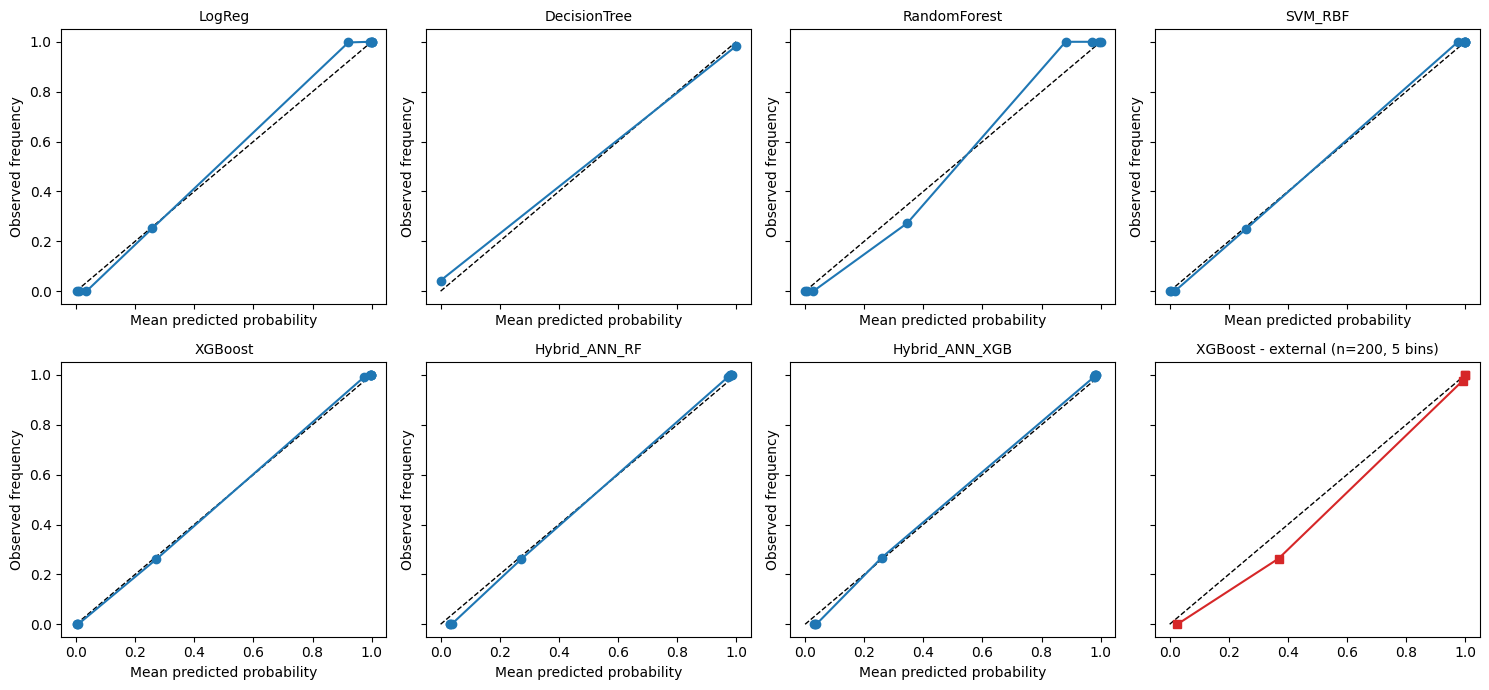

In [39]:
# R3-4: reliability plots + formal calibration statistics
import statsmodels.api as sm
from scipy.stats import chi2, norm
from sklearn.calibration import calibration_curve

def _logit(p): p = np.clip(p, 1e-4, 1-1e-4); return np.log(p/(1-p))
def calib_stats(y, p, groups=10):
    y = np.asarray(y, float); p = np.asarray(p, float); n = len(y)
    B = np.mean((p-y)**2); VB = np.sum(((1-2*p)**2)*p*(1-p))/n**2
    spieg = 2*norm.sf(abs((B - np.mean(p*(1-p)))/np.sqrt(VB))) if VB > 0 else np.nan          # Spiegelhalter Z-test
    try:
        lp = _logit(p)
        slope = sm.GLM(y, sm.add_constant(lp), family=sm.families.Binomial()).fit().params[1]    # calibration slope
        citl = sm.GLM(y, np.ones((n, 1)), family=sm.families.Binomial(), offset=lp).fit().params[0]  # calibration-in-the-large
    except Exception:
        slope = citl = np.nan
    g = pd.qcut(pd.Series(p).rank(method='first'), groups, labels=False)                        # Hosmer-Lemeshow (deciles of risk)
    hl = 0.0
    for k in range(groups):
        mk = (g == k).values; ng = mk.sum(); pi = np.clip(p[mk].mean(), 1e-6, 1-1e-6)
        hl += (y[mk].sum() - ng*pi)**2 / (ng*pi*(1-pi))
    bins = np.linspace(0, 1, 11); ece = 0.0
    for i in range(10):
        mk = (p > bins[i]) & (p <= bins[i+1]) if i else (p >= 0) & (p <= bins[1])
        if mk.any(): ece += mk.mean()*abs(y[mk].mean() - p[mk].mean())
    return {'Brier': B, 'ECE': ece, 'Slope': slope, 'CITL': citl, 'HL p': chi2.sf(hl, groups-2), 'Spiegelhalter p': spieg}

rows = []
for n in MODEL_NAMES:
    S = pd.DataFrame([calib_stats(repeat_y[r], repeat_oof[r][n]) for r in range(N_REPEATS)])
    med, lo, hi = S.median(), S.min(), S.max()
    rows.append({'Model': n, **{k: f"{med[k]:.3g} [{lo[k]:.3g}-{hi[k]:.3g}]" for k in S.columns}})
tab8 = pd.DataFrame(rows)
print("Calibration statistics: median [min-max] across the 10 CV repeats (400 pooled out-of-fold predictions each)")
print("Ideal: slope = 1, CITL = 0; HL p and Spiegelhalter p > 0.05 = no evidence of miscalibration\n")
print("Note: Decision Tree outputs are 0/1 probabilities, so slope, CITL and Spiegelhalter are degenerate - report them as 'not interpretable'.\n")
print(tab8.to_string(index=False)); tab8.to_csv('table_calibration_stats.csv', index=False)

fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True, sharey=True)
for ax, n in zip(axes.ravel(), MODEL_NAMES):
    yy = np.concatenate([repeat_y[r] for r in range(N_REPEATS)]); pp = np.concatenate([repeat_oof[r][n] for r in range(N_REPEATS)])
    fp_, mp_ = calibration_curve(yy, pp, n_bins=10, strategy='quantile')
    ax.plot([0, 1], [0, 1], 'k--', lw=1); ax.plot(mp_, fp_, 'o-'); ax.set_title(n, fontsize=10)
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed frequency')
if len(MODEL_NAMES) < 8: axes.ravel()[-1].axis('off')
if 'ext_proba_fixed' in globals():                                                                # external cohort in the spare panel
    ax = axes.ravel()[7]; ax.axis('on')
    fp_, mp_ = calibration_curve(y_ext_shared, ext_proba_fixed, n_bins=5, strategy='quantile')
    ax.plot([0, 1], [0, 1], 'k--', lw=1); ax.plot(mp_, fp_, 's-', color='C3'); ax.set_title('XGBoost - external (n=200, 5 bins)', fontsize=10)
    es = calib_stats(y_ext_shared, ext_proba_fixed, groups=5)
    print("\nEXTERNAL XGBoost:", {k: round(v, 4) for k, v in es.items()}, "(slope/CITL unstable under near-perfect separation)")
plt.tight_layout(); plt.savefig('reliability_plots.png', dpi=300); plt.show()

accuracy by number of truly missing values per patient (is the model right where real values exist?)

In [40]:
from scipy.stats import beta
def cp_ci(k, n, a=0.05):
    return (0.0 if k == 0 else beta.ppf(a/2, k, n-k+1)), (1.0 if k == n else beta.ppf(1-a/2, k+1, n-k))

n_miss = miss.sum(axis=1).values                       # truly missing cells per patient
strata = {'0 missing (complete)': n_miss == 0, '1-2 missing': (n_miss >= 1) & (n_miss <= 2), '>=3 missing': n_miss >= 3}
Xa, ya = df.drop(columns='Class').values, df['Class'].values

orders = []                                            # test-row order of each repeat's out-of-fold vector (same folds as cell 3)
for r in range(N_REPEATS):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + r)
    orders.append(np.concatenate([te for _, te in skf.split(Xa, ya)]))
    assert np.array_equal(ya[orders[-1]], repeat_y[r]), "fold order differs from cell 3"

oof_src = {n: [repeat_oof[r][n] for r in range(N_REPEATS)] for n in MODEL_NAMES}
if 'ext_oof' in globals():
    for n in ext_oof[0]: oof_src[n] = [ext_oof[r][n] for r in range(N_REPEATS)]
show = [m for m in ['LogReg', 'RandomForest', 'XGBoost', 'Hybrid_ANN_XGB', 'SoftVote_LR_RF_SVM_XGB'] if m in oof_src]

print("CKD prevalence by number of truly missing cells per patient:")
print(pd.DataFrame({'n_missing': n_miss, 'CKD': ya}).groupby('n_missing').CKD.agg(['count', 'mean']).round(3).T.to_string(), "\n")

rows = []
for sname, mask in strata.items():
    n_pat = int(mask.sum())
    for mdl in show:
        accs, tp, fn, tn, fp = [], 0, 0, 0, 0
        for r in range(N_REPEATS):
            idx = orders[r]; sel = mask[idx]; yt = ya[idx][sel]; pr = (oof_src[mdl][r][sel] >= .5).astype(int)
            accs.append((pr == yt).mean())
            tp += ((pr == 1) & (yt == 1)).sum(); fn += ((pr == 0) & (yt == 1)).sum()
            tn += ((pr == 0) & (yt == 0)).sum(); fp += ((pr == 1) & (yt == 0)).sum()
        k = int(round(np.mean(accs) * n_pat)); lo, hi = cp_ci(k, n_pat)
        rows.append({'Stratum': sname, 'Model': mdl, 'Patients': n_pat, 'CKD prevalence %': round(100 * ya[mask].mean(), 1),
                     'Accuracy % [95% CI]': f"{100*np.mean(accs):.1f} [{100*lo:.1f}, {100*hi:.1f}]",
                     'Sens %': round(100 * tp / (tp + fn), 1) if tp + fn else np.nan,
                     'Spec %': round(100 * tn / (tn + fp), 1) if tn + fp else np.nan})
tab_strata = pd.DataFrame(rows)
print(tab_strata.to_string(index=False)); tab_strata.to_csv('table_missingness_strata.csv', index=False)
print("\nReading guide: high accuracy in the '0 missing' stratum means the model is right where all values are real.")
print("Exact CIs use the mean per-repeat count on the stratum's patients (repeats are not treated as independent).")

CKD prevalence by number of truly missing cells per patient:
n_missing        0       1     2       3       4     5     6     7    8    9
count      169.000  53.000  30.0  46.000  39.000  17.0  22.0  13.0  6.0  5.0
mean         0.302   0.774   0.7   0.891   0.846   1.0   1.0   1.0  1.0  1.0 

             Stratum                  Model  Patients  CKD prevalence % Accuracy % [95% CI]  Sens %  Spec %
0 missing (complete)                 LogReg       169              30.2 100.0 [97.8, 100.0]   100.0   100.0
0 missing (complete)           RandomForest       169              30.2 100.0 [97.8, 100.0]   100.0   100.0
0 missing (complete)                XGBoost       169              30.2 100.0 [97.8, 100.0]   100.0   100.0
0 missing (complete)         Hybrid_ANN_XGB       169              30.2 100.0 [97.8, 100.0]   100.0   100.0
0 missing (complete) SoftVote_LR_RF_SVM_XGB       169              30.2 100.0 [97.8, 100.0]   100.0   100.0
         1-2 missing                 LogReg        83     

## 8. Summary cells (executive summary, tables, dashboard)

In [41]:
# === 7.1 Executive summary: the four headline findings, in one place ===
print("="*78)
print("HEADLINE FINDING 1 — Architecture choice is statistically indistinguishable")
print("="*78)
top_model = results_df.iloc[0]
print(f"Best model: {top_model['Model']} | Acc: {top_model['Acc mean']*100:.2f}% {top_model['Acc 95% CI']}")
n_sig = sig_df['Significant (a=.05)'].sum()
print(f"Significant pairwise differences (Holm-corrected, 21 pairs): {n_sig} / {len(sig_df)}")
print()

print("="*78)
print("HEADLINE FINDING 2 — Missingness correlates with the label; effect of removing the columns")
print("="*78)
print(f"Missingness-only model (no clinical values): Acc {acc_scores.mean()*100:.1f}% | AUC {auc_scores.mean():.3f}")
v1_acc = variant_results['V1 Baseline (current papers)']['acc'].mean()
v4_acc = variant_results['V4 No-leak floor']['acc'].mean()
print(f"V1 (all 13 features): {v1_acc*100:.2f}%  ->  V4 (5 leak-cols removed): {v4_acc*100:.2f}%")
print(f"Drop: {(v1_acc-v4_acc)*100:.2f} pp | corrected paired test p = {p_v1v4:.3f} (non-significant is NOT proof of equivalence; see ground-truth audit + in-fold imputation sections)")
print()

print("="*78)
print("HEADLINE FINDING 3 — Performance on ONE independent cohort (single site, retrospective)")
print("="*78)
print(f"In-dataset (12 shared features, 10-repeat CV): {accs_reduced.mean()*100:.2f}%")
print(f"External validation (Dhaka, Bangladesh, n=200): {ext_acc_fixed*100:.2f}% | AUC {ext_auc_fixed:.4f}")
print(f"Gap: {(accs_reduced.mean()-ext_acc_fixed)*100:.2f} pp | accuracy before vs after Rbc fix: {ext_acc:.4f} vs {ext_acc_fixed:.4f}")
print(f"Zero false negatives: {confusion_matrix(y_ext_shared, ext_pred_fixed)[1,0]} missed CKD cases out of 128")
print()

print("="*78)
print("HEADLINE FINDING 4 — Diagnostic signal is concentrated in 3 features")
print("="*78)
top3 = importance_df.head(3)
print(f"Top 3 features account for {top3['Importance'].sum()*100:.1f}% of SPLIT-GAIN importance (cite the SHAP share from the SHAP section in the paper):")
for _, row in top3.iterrows():
    print(f"  {row['Feature']}: {row['Importance']*100:.1f}%")
zero_feats = importance_df[importance_df['Importance'] < 0.001]['Feature'].tolist()
print(f"Features with ~zero importance: {zero_feats}")

HEADLINE FINDING 1 — Architecture choice is statistically indistinguishable
Best model: Hybrid_ANN_XGB | Acc: 98.90% [97.76%, 100.00%]
Significant pairwise differences (Holm-corrected, 21 pairs): 0 / 21

HEADLINE FINDING 2 — Missingness correlates with the label; effect of removing the columns
Missingness-only model (no clinical values): Acc 72.2% | AUC 0.766
V1 (all 13 features): 98.75%  ->  V4 (5 leak-cols removed): 97.08%
Drop: 1.67 pp | corrected paired test p = 0.070 (non-significant is NOT proof of equivalence; see ground-truth audit + in-fold imputation sections)

HEADLINE FINDING 3 — Performance on ONE independent cohort (single site, retrospective)
In-dataset (12 shared features, 10-repeat CV): 98.75%
External validation (Dhaka, Bangladesh, n=200): 98.00% | AUC 0.9985
Gap: 0.75 pp | accuracy before vs after Rbc fix: 0.9800 vs 0.9800
Zero false negatives: 0 missed CKD cases out of 128

HEADLINE FINDING 4 — Diagnostic signal is concentrated in 3 features
Top 3 features account f

In [42]:
# === 7.2 Master results table: all models, ranked ===
master_table = results_df.copy()
master_table['Acc mean'] = (master_table['Acc mean']*100).round(2)
master_table['AUC mean'] = master_table['AUC mean'].round(4)
master_table['F1 mean'] = master_table['F1 mean'].round(4)
master_table['Brier mean'] = master_table['Brier mean'].round(4)
master_table = master_table[['Model', 'Acc mean', 'Acc 95% CI', 'AUC mean', 'F1 mean', 'Brier mean']]
master_table.columns = ['Model', 'Accuracy (%)', '95% CI', 'AUC', 'F1', 'Brier Score']
master_table

,Model,Accuracy (%),95% CI,AUC,F1,Brier Score
0,Hybrid_ANN_XGB,98.90,"[97.76%, 100.00%]",0.9995,0.9912,0.0098
1,RandomForest,98.75,"[97.63%, 99.87%]",0.9998,0.9901,0.0112
2,XGBoost,98.60,"[97.35%, 99.85%]",0.9996,0.9888,0.0097
3,Hybrid_ANN_RF,98.45,"[97.02%, 99.88%]",0.9996,0.9876,0.0110
4,SVM_RBF,98.35,"[96.99%, 99.71%]",0.9996,0.9867,0.0097
5,LogReg,97.95,"[96.51%, 99.39%]",0.9994,0.9834,0.0133
6,DecisionTree,97.32,"[95.74%, 98.91%]",0.9730,0.9784,0.0268


In [43]:
# === 7.3 Ablation summary table (V1-V5) ===
ablation_summary = pd.DataFrame([
    {'Variant': name, 'Description': desc, 'Accuracy (%)': variant_results[name]['acc'].mean()*100,
     'AUC': variant_results[name]['auc'].mean()}
    for name, desc in [
        ('V1 Baseline (current papers)', 'Raw imputed values (what every published paper uses)'),
        ('V2 Transparent (+flags)', 'V1 + explicit "was imputed" indicator features'),
        ('V3 KNN re-imputed', 'Imputed constants -> NaN -> 5-NN re-imputation'),
        ('V4 No-leak floor', 'Five leak-prone columns removed entirely'),
        ('V5 Floor + flags only', 'V4 + imputation flags, no raw leaky values'),
    ]
]).round(3)
ablation_summary

,Variant,Description,Accuracy (%),AUC
0,V1 Baseline (current papers),Raw imputed values (what every published paper...,98.750,1.000
1,V2 Transparent (+flags),"V1 + explicit ""was imputed"" indicator features",98.925,1.000
2,V3 KNN re-imputed,Imputed constants -> NaN -> 5-NN re-imputation,98.550,0.999
3,V4 No-leak floor,Five leak-prone columns removed entirely,97.075,0.997
4,V5 Floor + flags only,"V4 + imputation flags, no raw leaky values",98.000,0.999


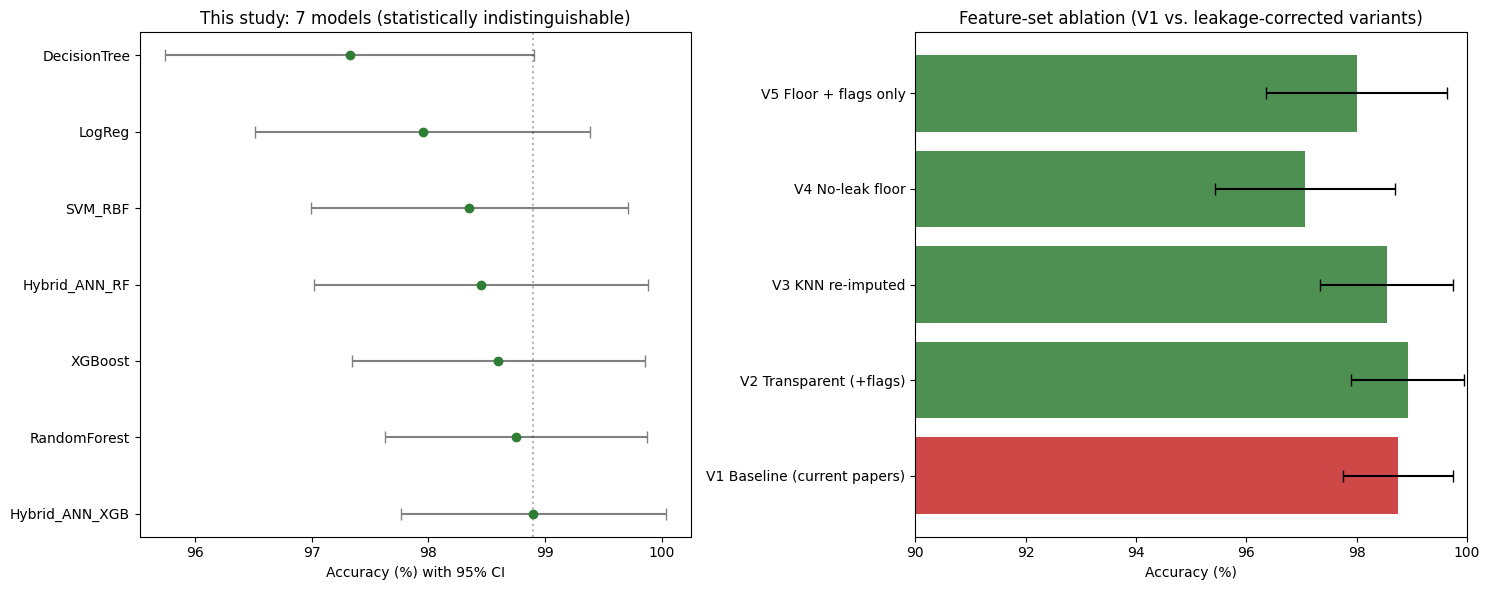

Saved: results_dashboard.png


In [44]:
# === 7.4 Final combined figure: model accuracy + literature CI + external validation ===
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: your 7 models with CI
ax = axes[0]
y_positions = np.arange(len(results_df))
centers, errs = [], []
for _, row in results_df.iterrows():
    n_folds = len(fold_metrics[row['Model']]['acc'])
    acc_arr = np.array(fold_metrics[row['Model']]['acc'])
    ci = nb_ci_halfwidth(acc_arr)          # Nadeau-Bengio-corrected CI
    centers.append(row['Acc mean']*100)
    errs.append(ci*100)
ax.errorbar(centers, y_positions, xerr=errs, fmt='o', capsize=4, color='#2E7D32', ecolor='gray')
ax.set_yticks(y_positions); ax.set_yticklabels(results_df['Model'])
ax.set_xlabel('Accuracy (%) with 95% CI')
ax.set_title('This study: 7 models (statistically indistinguishable)')
ax.axvline(x=max(centers), color='black', linestyle=':', alpha=0.3)

# Right: ablation variants
ax2 = axes[1]
variant_order = list(variant_results.keys())
v_means = [variant_results[v]['acc'].mean()*100 for v in variant_order]
v_stds = [variant_results[v]['acc'].std()*100 for v in variant_order]
colors_v = ['#C62828' if 'V1' in v else '#2E7D32' for v in variant_order]
ax2.barh(variant_order, v_means, xerr=v_stds, color=colors_v, capsize=4, alpha=0.85)
ax2.set_xlabel('Accuracy (%)')
ax2.set_title('Feature-set ablation (V1 vs. leakage-corrected variants)')
ax2.set_xlim(90, 100)

plt.tight_layout()
plt.savefig('results_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_dashboard.png")

In [45]:
# === 7.5 One-line abstract-ready summary string ===
summary_line = (
    f"Across seven architectures (LogReg to hybrid ANN+XGBoost stacks), accuracy differences were "
    f"statistically indistinguishable ({n_sig}/{len(sig_df)} pairs significant after Holm-Bonferroni correction). "
    f"A missingness-indicator audit revealed that {(X_missing_only.sum(axis=1)>0).sum()}/{len(df)} records "
    f"carried mean-imputed lab values strongly correlated with the diagnostic label "
    f"(missingness-only model: {acc_scores.mean()*100:.1f}% accuracy), yet removing these features cost only "
    f"{(v1_acc-v4_acc)*100:.2f} percentage points (corrected p = {p_v1v4:.3f}; non-significance does not establish equivalence). "
    f"External validation on one independent Bangladeshi cohort (n=200) gave: "
    f"{ext_acc_fixed*100:.2f}% accuracy (AUC {ext_auc_fixed:.4f}), a gap of only "
    f"{(accs_reduced.mean()-ext_acc_fixed)*100:.2f} percentage points from in-dataset performance, with zero missed CKD cases (single-site, retrospective; interpret cautiously)."
)
print(summary_line)

Across seven architectures (LogReg to hybrid ANN+XGBoost stacks), accuracy differences were statistically indistinguishable (0/21 pairs significant after Holm-Bonferroni correction). A missingness-indicator audit revealed that 166/400 records carried mean-imputed lab values strongly correlated with the diagnostic label (missingness-only model: 72.2% accuracy), yet removing these features cost only 1.67 percentage points (corrected p = 0.070; non-significance does not establish equivalence). External validation on one independent Bangladeshi cohort (n=200) gave: 98.00% accuracy (AUC 0.9985), a gap of only 0.75 percentage points from in-dataset performance, with zero missed CKD cases (single-site, retrospective; interpret cautiously).


## 9. Explainability (SHAP), correlation analysis, decision-curve analysis

In [46]:
# Duplicate/near-duplicate check between training set and "external" set,
# on the 12 shared columns, before trusting the external validation number.
tol = 1e-3
train_arr = X_train_shared.values
ext_arr = X_ext_shared.values  # or X_ext_shared_fixed, same columns

n_matches = 0
match_pairs = []
for i, ext_row in enumerate(ext_arr):
    diffs = np.abs(train_arr - ext_row)
    close = np.all(diffs < tol, axis=1)
    if close.any():
        n_matches += 1
        match_pairs.append((i, np.where(close)[0].tolist()))

print(f"External rows with a near-exact match in training set: {n_matches} / {len(ext_arr)}")
if match_pairs[:5]:
    print("Example matches (external_idx -> train_idx list):", match_pairs[:5])

External rows with a near-exact match in training set: 0 / 200


In [47]:
# === 17b. Sanity check before SHAP/DCA — catches stale-kernel variable drift ===
print("X_train_shared:", X_train_shared.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("y_train_shared:", y_train_shared.shape)
print("X_ext_shared_fixed:", X_ext_shared_fixed.shape)
print("X_ext_scaled_fixed:", X_ext_scaled_fixed.shape)
print("y_ext_shared:", y_ext_shared.shape)
print("ext_pred_fixed:", ext_pred_fixed.shape)
print("ext_proba_fixed:", ext_proba_fixed.shape)

assert X_train_scaled.shape[0] == X_train_shared.shape[0] == y_train_shared.shape[0], \
    "Training arrays out of sync — rerun cells 32-34 in order."
assert X_ext_scaled_fixed.shape[0] == y_ext_shared.shape[0] == ext_pred_fixed.shape[0] == ext_proba_fixed.shape[0], \
    "External arrays out of sync (this is what caused your ValueError) — rerun cells 32, 34, 36 in order."
print("\nAll shapes consistent — safe to proceed to SHAP/DCA cells.")

X_train_shared: (400, 12)
X_train_scaled: (400, 12)
y_train_shared: (400,)
X_ext_shared_fixed: (200, 12)
X_ext_scaled_fixed: (200, 12)
y_ext_shared: (200,)
ext_pred_fixed: (200,)
ext_proba_fixed: (200,)

All shapes consistent — safe to proceed to SHAP/DCA cells.


In [48]:
# === Guard: make sure no cell has substituted train-as-external ===
assert not np.allclose(X_ext_shared_fixed.values[:min(50,len(X_ext_shared_fixed))],
                         X_train_shared.values[:min(50,len(X_ext_shared_fixed))]), \
    "X_ext_shared_fixed looks identical to X_train_shared — a stand-in/test cell has overwritten your real external data. Check for leftover syntax-test cells above this point and delete them."

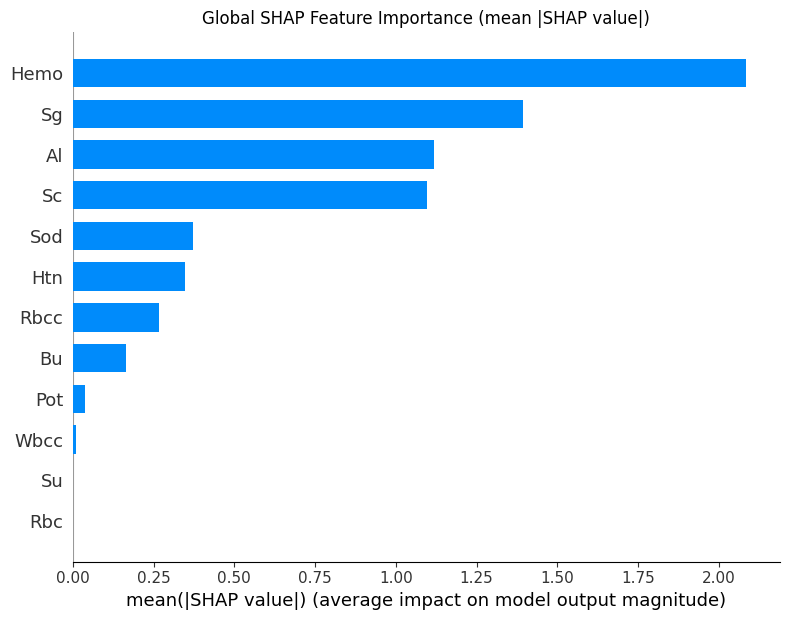

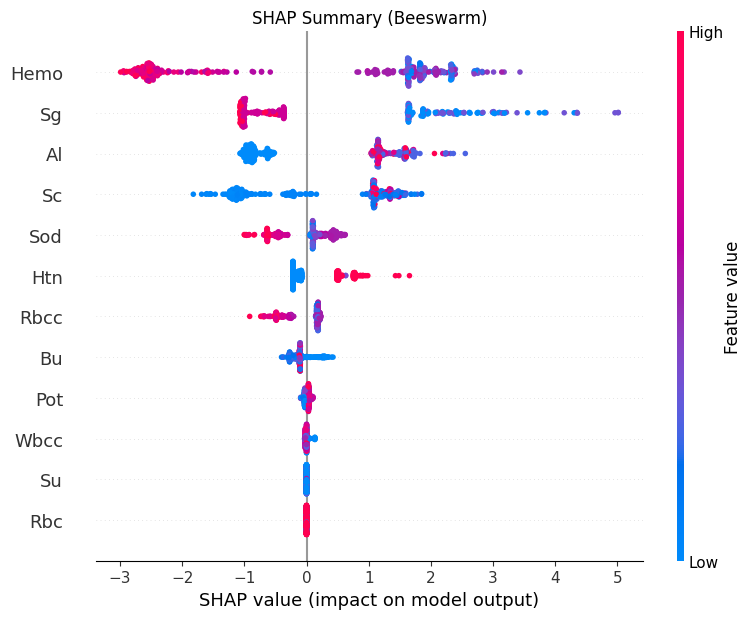

   Feature  Mean |SHAP|  % of total
0     Hemo     2.085069   30.200001
1       Sg     1.393723   20.200001
2       Al     1.119211   16.200001
3       Sc     1.096498   15.900000
4      Sod     0.372994    5.400000
5      Htn     0.348068    5.000000
6     Rbcc     0.267827    3.900000
7       Bu     0.164435    2.400000
8      Pot     0.037444    0.500000
9     Wbcc     0.011288    0.200000
10     Rbc     0.000000    0.000000
11      Su     0.000000    0.000000

Top-3 features account for 66.6% of total mean |SHAP| (cite this number, not the split-importance one, in 4.5)


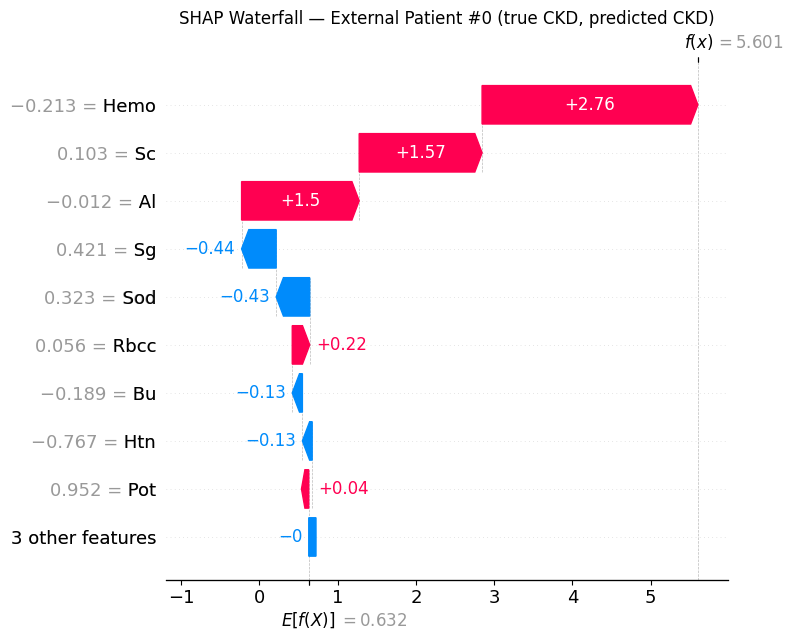

In [49]:
# === 18. SHAP-based explainability (real computation, not just installed) ===
import shap

# TreeExplainer works directly on XGBoost; use SCALED data with column names
# so plots show feature names but respect the same scaling the model was trained on.
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_shared.columns)
X_ext_scaled_df    = pd.DataFrame(X_ext_scaled_fixed, columns=X_train_shared.columns)

explainer = shap.TreeExplainer(final_model)

# Global explanations computed on the training set (this is what generalizes to "how
# the model behaves", as opposed to only explaining test-set quirks)
shap_values_train = explainer.shap_values(X_train_scaled_df)

# --- 18a. Global bar plot: mean absolute SHAP value per feature ---
plt.figure()
shap.summary_plot(shap_values_train, X_train_scaled_df, plot_type='bar', show=False)
plt.title('Global SHAP Feature Importance (mean |SHAP value|)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 18b. Beeswarm: direction + magnitude of each feature's effect ---
plt.figure()
shap.summary_plot(shap_values_train, X_train_scaled_df, show=False)
plt.title('SHAP Summary (Beeswarm)')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 18c. Print the actual ranked numbers so the paper text can cite exact figures ---
mean_abs_shap = pd.DataFrame({
    'Feature': X_train_shared.columns,
    'Mean |SHAP|': np.abs(shap_values_train).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
mean_abs_shap['% of total'] = (mean_abs_shap['Mean |SHAP|'] / mean_abs_shap['Mean |SHAP|'].sum() * 100).round(1)
print(mean_abs_shap)

top3_pct = mean_abs_shap['% of total'].iloc[:3].sum()
print(f"\nTop-3 features account for {top3_pct:.1f}% of total mean |SHAP| (cite this number, not the split-importance one, in 4.5)")

# --- 18d. Single-patient waterfall plot ---
# Pick a true-CKD external patient the model got right, so the story is representative.
correct_ckd_idx = np.where((y_ext_shared == 1) & (ext_pred_fixed == 1))[0]
patient_idx = correct_ckd_idx[0]  # first such patient; change index to pick another

explainer_ext = shap.TreeExplainer(final_model)
shap_values_patient = explainer_ext(X_ext_scaled_df.iloc[[patient_idx]])

plt.figure()
shap.plots.waterfall(shap_values_patient[0], show=False)
plt.title(f'SHAP Waterfall — External Patient #{patient_idx} (true CKD, predicted CKD)')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

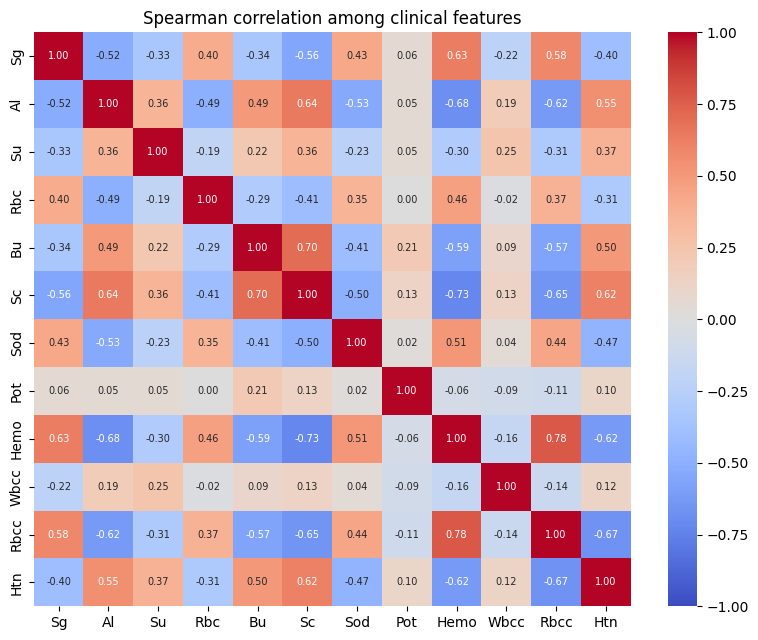

Pairs with |Spearman rho| >= 0.5:
  Hemo  - Rbcc   rho = +0.78
  Sc    - Hemo   rho = -0.73
  Bu    - Sc     rho = +0.70
  Al    - Hemo   rho = -0.68
  Rbcc  - Htn    rho = -0.67
  Sc    - Rbcc   rho = -0.65
  Al    - Sc     rho = +0.64
  Sg    - Hemo   rho = +0.63
  Al    - Rbcc   rho = -0.62
  Hemo  - Htn    rho = -0.62
  Sc    - Htn    rho = +0.62
  Bu    - Hemo   rho = -0.59
  Sg    - Rbcc   rho = +0.58
  Bu    - Rbcc   rho = -0.57
  Sg    - Sc     rho = -0.56
  Al    - Htn    rho = +0.55
  Al    - Sod    rho = -0.53
  Sg    - Al     rho = -0.52
  Sod   - Hemo   rho = +0.51
  Bu    - Htn    rho = +0.50

VIF: {'Sg': np.float64(1.56), 'Al': np.float64(1.85), 'Su': np.float64(1.2), 'Rbc': np.float64(1.23), 'Bu': np.float64(2.2), 'Sc': np.float64(2.36), 'Sod': np.float64(1.91), 'Pot': np.float64(1.27), 'Hemo': np.float64(2.67), 'Wbcc': np.float64(1.11), 'Rbcc': np.float64(2.08), 'Htn': np.float64(1.75)}

Group-level SHAP (mean |sum of SHAP within group|, signed sum allows cancellation)

In [50]:
# R3-6: correlation structure behind the SHAP ranking (group SHAP, VIF, leave-one-feature-out)
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

feat = list(X_train_shared.columns)
obs = df_nan[feat] if 'df_nan' in globals() else X_train_shared          # observed-only values if NEW-1 was run
corr = obs.corr(method='spearman')

plt.figure(figsize=(8, 6.5)); sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Spearman correlation among clinical features'); plt.tight_layout(); plt.savefig('feature_correlation.png', dpi=300); plt.show()

pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(feat) for b in feat[i+1:] if abs(corr.loc[a, b]) >= 0.5]
print("Pairs with |Spearman rho| >= 0.5:"); [print(f"  {a:5s} - {b:5s}  rho = {r:+.2f}") for a, b, r in sorted(pairs, key=lambda x: -abs(x[2]))]

Z = sm.add_constant(StandardScaler().fit_transform(X_train_shared.values))
print("\nVIF:", {f: round(variance_inflation_factor(Z, i+1), 2) for i, f in enumerate(feat)})

# data-driven feature groups (average linkage on 1-|rho|, cut at distance 0.5)
D = 1 - corr.abs().fillna(0).values; np.fill_diagonal(D, 0)
lab = hierarchy.fcluster(hierarchy.linkage(squareform(D, checks=False), 'average'), t=0.5, criterion='distance')
groups = {k: [feat[i] for i in np.where(lab == k)[0]] for k in np.unique(lab)}
sv = np.asarray(shap_values_train); tot = np.abs(sv).mean(0).sum()
print("\nGroup-level SHAP (mean |sum of SHAP within group|, signed sum allows cancellation):")
for k, mem in sorted(groups.items(), key=lambda kv: -np.abs(sv[:, [feat.index(m) for m in kv[1]]].sum(1)).mean()):
    g = np.abs(sv[:, [feat.index(m) for m in mem]].sum(1)).mean()
    print(f"  {', '.join(mem):28s} {g:6.3f}  ({100*g/tot:4.1f}% of sum of single-feature mean|SHAP|)")

# leave-one-feature-out: if a top feature is redundant, accuracy barely moves (needs cell '# 14' evaluate_variant)
top4 = list(mean_abs_shap['Feature'].iloc[:4])
base_acc, _ = evaluate_variant(X_train_shared, y_train_shared, model_name='XGBoost', n_repeats=N_REPEATS)
print(f"\nAll 12 features: {base_acc.mean()*100:.2f}%")
for f in top4:
    a, _ = evaluate_variant(X_train_shared.drop(columns=f), y_train_shared, model_name='XGBoost', n_repeats=N_REPEATS)
    print(f"  without {f:5s}: {a.mean()*100:.2f}%  (change {100*(a.mean()-base_acc.mean()):+.2f} pp)")

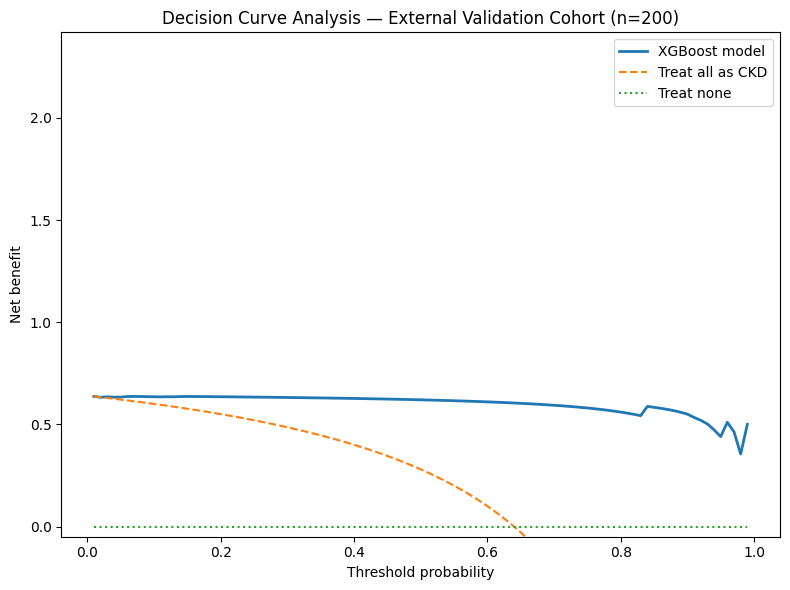

Model shows positive net benefit over reference strategies for thresholds 0.03–0.99
McNemar contingency table [[both correct, model-only correct],[baseline-only correct, both wrong]]:
[[np.int64(194), np.int64(2)], [np.int64(3), np.int64(1)]]

McNemar's exact test: statistic=2.0, p-value=1.00000
XGBoost external accuracy: 0.9800
Logistic Regression external accuracy: 0.9850

Bootstrap 95% CI for external accuracy (2000 resamples): [0.9600, 0.9950]
Point estimate: 0.9800


In [51]:
# === 19. Decision Curve Analysis, McNemar's test, bootstrap CI — on the REAL external cohort ===
from statsmodels.stats.contingency_tables import mcnemar

# --- 19a. Decision Curve Analysis ---
def net_benefit(y_true, y_prob, threshold):
    """Net benefit of treating-if-predicted-positive at a given threshold probability."""
    pred_pos = (y_prob >= threshold).astype(int)
    tp = np.sum((pred_pos == 1) & (y_true == 1))
    fp = np.sum((pred_pos == 1) & (y_true == 0))
    n = len(y_true)
    return (tp / n) - (fp / n) * (threshold / (1 - threshold))

thresholds = np.linspace(0.01, 0.99, 99)
nb_model     = [net_benefit(y_ext_shared, ext_proba_fixed, t) for t in thresholds]
nb_treat_all = [ (np.sum(y_ext_shared==1)/len(y_ext_shared)) - (np.sum(y_ext_shared==0)/len(y_ext_shared)) * (t/(1-t)) for t in thresholds]
nb_treat_none = [0.0 for _ in thresholds]

plt.figure(figsize=(8,6))
plt.plot(thresholds, nb_model, label='XGBoost model', linewidth=2)
plt.plot(thresholds, nb_treat_all, label='Treat all as CKD', linestyle='--')
plt.plot(thresholds, nb_treat_none, label='Treat none', linestyle=':')
plt.ylim(bottom=-0.05)
plt.xlabel('Threshold probability')
plt.ylabel('Net benefit')
plt.title('Decision Curve Analysis — External Validation Cohort (n=200)')
plt.legend()
plt.tight_layout()
plt.savefig('decision_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Report the threshold range over which the model beats BOTH reference strategies
useful_range = [t for t, nb in zip(thresholds, nb_model)
                if nb > max(0, (np.sum(y_ext_shared==1)/len(y_ext_shared)) - (np.sum(y_ext_shared==0)/len(y_ext_shared)) * (t/(1-t)))]
if useful_range:
    print(f"Model shows positive net benefit over reference strategies for thresholds {min(useful_range):.2f}–{max(useful_range):.2f}")
else:
    print("Model does not beat both reference strategies at any tested threshold — report this honestly if it happens.")

# --- 19b. Baseline comparator for McNemar's test (paired predictions, same patients) ---
# Using Logistic Regression as the baseline strategy, trained identically to final_model.
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train_shared)
baseline_pred_ext = baseline_model.predict(X_ext_scaled_fixed)

# Build the 2x2 paired contingency table: model correct/incorrect vs baseline correct/incorrect
model_correct    = (ext_pred_fixed == y_ext_shared)
baseline_correct = (baseline_pred_ext == y_ext_shared)

both_correct        = np.sum(model_correct & baseline_correct)
model_only_correct  = np.sum(model_correct & ~baseline_correct)
baseline_only_correct = np.sum(~model_correct & baseline_correct)
both_wrong          = np.sum(~model_correct & ~baseline_correct)

contingency = [[both_correct, model_only_correct],
               [baseline_only_correct, both_wrong]]
print("McNemar contingency table [[both correct, model-only correct],[baseline-only correct, both wrong]]:")
print(contingency)

result = mcnemar(contingency, exact=True)
print(f"\nMcNemar's exact test: statistic={result.statistic}, p-value={result.pvalue:.5f}")
print(f"XGBoost external accuracy: {accuracy_score(y_ext_shared, ext_pred_fixed):.4f}")
print(f"Logistic Regression external accuracy: {accuracy_score(y_ext_shared, baseline_pred_ext):.4f}")

# --- 19c. Bootstrap 95% CI for external accuracy ---
rng = np.random.default_rng(42)
n_boot = 2000
n_ext = len(y_ext_shared)
boot_accs = np.zeros(n_boot)

for b in range(n_boot):
    idx = rng.integers(0, n_ext, n_ext)  # resample with replacement
    boot_accs[b] = accuracy_score(y_ext_shared[idx], ext_pred_fixed[idx])

ci_lower, ci_upper = np.percentile(boot_accs, [2.5, 97.5])
print(f"\nBootstrap 95% CI for external accuracy (2000 resamples): [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Point estimate: {accuracy_score(y_ext_shared, ext_pred_fixed):.4f}")

Prevalence = 0.640. Treat-all net benefit falls below zero (below treat-none) once threshold > prevalence,
so comparisons above ~0.64 are not informative.

 Threshold  NB model         95% CI  NB treat-all  NB diff    diff 95% CI  Net unnecessary referrals avoided /100
      0.05     0.633 [0.566, 0.695]         0.621    0.012 [0.009, 0.015]                                    23.0
      0.10     0.635 [0.566, 0.697]         0.600    0.035 [0.028, 0.042]                                    31.5
      0.20     0.635 [0.566, 0.698]         0.550    0.085 [0.070, 0.101]                                    34.0
      0.30     0.631 [0.561, 0.694]         0.486    0.146 [0.120, 0.174]                                    34.0
      0.50     0.620 [0.545, 0.690]         0.280    0.340 [0.280, 0.405]                                    34.0

External calibration: mean predicted risk 0.668 vs observed prevalence 0.640 | Brier 0.0174 | ECE 0.0281


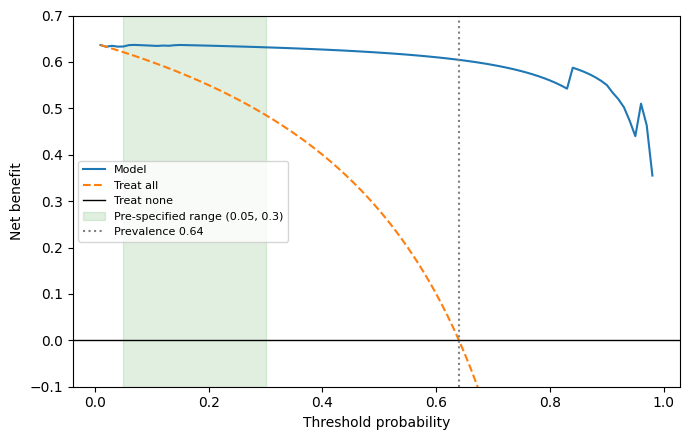

In [52]:
# R2-5: DCA - pre-specified threshold range, bootstrap CIs, external calibration
y_e, p_e = np.asarray(y_ext_shared), np.asarray(ext_proba_fixed)
prev = y_e.mean()

def nb_model(y, p, t):
    pred = p >= t; n = len(y)
    return ((pred & (y == 1)).sum() - (pred & (y == 0)).sum() * t/(1-t)) / n
def nb_all(y, t):
    pr = y.mean(); return pr - (1-pr) * t/(1-t)

CLIN_RANGE = (0.05, 0.30)       # pre-specified screening range (justify in text: missing CKD costs more than a confirmatory eGFR/ACR test)
print(f"Prevalence = {prev:.3f}. Treat-all net benefit falls below zero (below treat-none) once threshold > prevalence,")
print("so comparisons above ~0.64 are not informative.\n")

rng = np.random.default_rng(42); B = 2000; idx = [rng.integers(0, len(y_e), len(y_e)) for _ in range(B)]
rows = []
for t in [0.05, 0.10, 0.20, 0.30, 0.50]:
    m, a = nb_model(y_e, p_e, t), nb_all(y_e, t)
    bm = np.array([nb_model(y_e[i], p_e[i], t) for i in idx]); bd = np.array([nb_model(y_e[i], p_e[i], t) - nb_all(y_e[i], t) for i in idx])
    rows.append({'Threshold': t, 'NB model': round(m, 3), '95% CI': f"[{np.percentile(bm,2.5):.3f}, {np.percentile(bm,97.5):.3f}]",
                 'NB treat-all': round(a, 3), 'NB diff': round(m-a, 3), 'diff 95% CI': f"[{np.percentile(bd,2.5):.3f}, {np.percentile(bd,97.5):.3f}]",
                 'Net unnecessary referrals avoided /100': round(100*(m-a)/(t/(1-t)), 1)})
print(pd.DataFrame(rows).to_string(index=False))

# external calibration (DCA assumes calibrated probabilities)
def ece(y, p, nb=10):
    bins = np.linspace(0, 1, nb+1); e = 0
    for i in range(nb):
        mk = (p > bins[i]) & (p <= bins[i+1]) if i else (p >= bins[0]) & (p <= bins[1])
        if mk.any(): e += mk.mean() * abs(y[mk].mean() - p[mk].mean())
    return e
print(f"\nExternal calibration: mean predicted risk {p_e.mean():.3f} vs observed prevalence {prev:.3f} | "
      f"Brier {np.mean((p_e-y_e)**2):.4f} | ECE {ece(y_e, p_e):.4f}")

# figure
ts = np.arange(0.01, 0.99, 0.01)
plt.figure(figsize=(7, 4.5))
plt.plot(ts, [nb_model(y_e, p_e, t) for t in ts], label='Model')
plt.plot(ts, [nb_all(y_e, t) for t in ts], '--', label='Treat all')
plt.axhline(0, color='k', lw=1, label='Treat none')
plt.axvspan(*CLIN_RANGE, color='green', alpha=0.12, label=f'Pre-specified range {CLIN_RANGE}')
plt.axvline(prev, color='grey', ls=':', label=f'Prevalence {prev:.2f}')
plt.ylim(-0.1, 0.7); plt.xlabel('Threshold probability'); plt.ylabel('Net benefit'); plt.legend(fontsize=8); plt.tight_layout()
plt.savefig('decision_curve_v2.png', dpi=300); plt.show()

## 10. Reproducibility package (run last)
Builds `repro_package.zip` (processed data, fold assignments, out-of-fold predictions, tables, figures, environment, README). Upload it to GitHub and archive on Zenodo for a DOI. Check the licences of the UCI datasets before redistributing processed copies.

In [53]:
# R3-5: reproducibility package (RUN LAST)
import os, zipfile, platform, importlib.metadata as md
P = 'repro_package'; os.makedirs(P, exist_ok=True)
df.to_csv(f'{P}/new_model_input.csv', index=False)
if 'df_nan' in globals(): df_nan.assign(Class=df['Class']).to_csv(f'{P}/new_model_observed_only.csv', index=False); miss.to_csv(f'{P}/true_missingness_mask.csv', index=False)
X_ext_shared_fixed.assign(Class=y_ext_shared).to_csv(f'{P}/external_uci857_aligned.csv', index=False)
Xa, ya = df.drop(columns='Class').values, df['Class'].values
fold_rows, oof_rows = [], []
for r in range(N_REPEATS):
    order = []
    for k, (tr, te) in enumerate(StratifiedKFold(N_SPLITS, shuffle=True, random_state=RANDOM_STATE+r).split(Xa, ya)):
        fold_rows += [(r, k, int(i)) for i in te]; order += list(te)
    d = pd.DataFrame({'repeat': r, 'row_index': order, 'y_true': ya[order]})
    for n in MODEL_NAMES: d[n] = repeat_oof[r][n]
    if 'ext_oof' in globals():
        for n in ext_oof[r]: d[n] = ext_oof[r][n]
    oof_rows.append(d)
pd.DataFrame(fold_rows, columns=['repeat', 'fold', 'test_row_index']).to_csv(f'{P}/cv_fold_assignments.csv', index=False)
pd.concat(oof_rows).to_csv(f'{P}/oof_predictions.csv', index=False)
pd.DataFrame({n: pd.Series(v['acc']) for n, v in fold_metrics.items()}).to_csv(f'{P}/per_fold_accuracy.csv', index=False)
for nm in ['results_df', 'tab6', 'tab7', 'tab8', 'table1', 'audit_df']:
    if nm in globals(): globals()[nm].to_csv(f'{P}/{nm}.csv', index=False)
for f in ['reliability_plots.png', 'feature_correlation.png', 'decision_curve_v2.png', 'shap_bar.png', 'shap_beeswarm.png', 'shap_waterfall.png']:
    if os.path.exists(f): os.replace(f, f'{P}/{f}')
pk = ['numpy', 'pandas', 'scikit-learn', 'xgboost', 'tensorflow', 'shap', 'scipy', 'statsmodels', 'ucimlrepo']
env = [f"python {platform.python_version()}"] + [f"{p}=={md.version(p)}" for p in pk if p in {d.metadata['Name'].lower() for d in md.distributions()}]
open(f'{P}/requirements_used.txt', 'w').write('\n'.join(env))
open(f'{P}/README.md', 'w').write(f"""# CKD statistical audit - reproducibility package
Data: new_model_input.csv (pre-imputed UCI CKD, 400 x 14); UCI #857 is fetched with ucimlrepo (id=857, CC BY 4.0); original UCI CKD file via ucimlrepo (id=336).
Protocol: {N_SPLITS}-fold stratified CV x {N_REPEATS} repeats, seeds {RANDOM_STATE}..{RANDOM_STATE+N_REPEATS-1}; exact fold membership in cv_fold_assignments.csv.
Out-of-fold probabilities for every model: oof_predictions.csv. Scaling is fitted on training folds only.
Note: TensorFlow ANN results can differ slightly across hardware/versions even with fixed seeds.
Environment: requirements_used.txt. Run the notebook top to bottom (~1 h on Colab CPU).
""")
with zipfile.ZipFile('repro_package.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for root, _, fs in os.walk(P): [z.write(os.path.join(root, f)) for f in fs]
print(sorted(os.listdir(P)))
try:
    from google.colab import files; files.download('repro_package.zip')
except Exception: print("Not on Colab - repro_package.zip is in the working directory.")

['README.md', 'audit_df.csv', 'cv_fold_assignments.csv', 'decision_curve_v2.png', 'external_uci857_aligned.csv', 'feature_correlation.png', 'new_model_input.csv', 'new_model_observed_only.csv', 'oof_predictions.csv', 'per_fold_accuracy.csv', 'reliability_plots.png', 'requirements_used.txt', 'results_df.csv', 'shap_bar.png', 'shap_beeswarm.png', 'shap_waterfall.png', 'tab6.csv', 'tab7.csv', 'tab8.csv', 'table1.csv', 'true_missingness_mask.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.model_selection import cross_val_score as _cvs, RepeatedStratifiedKFold as _RSKF
_rcv = _RSKF(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)
_Xf = miss.astype(int).values; _yy = df['Class'].values
miss_acc = _cvs(_LR(max_iter=1000), _Xf, _yy, cv=_rcv, scoring='accuracy').mean()
miss_auc = _cvs(_LR(max_iter=1000), _Xf, _yy, cv=_rcv, scoring='roc_auc').mean()
n_any = int((miss.sum(axis=1) > 0).sum()); n_cells = int(miss.values.sum())
sig_cols = audit_df.loc[(audit_df['Fisher p'] < 0.05), 'Column'].tolist()
n_cols_missing = int((audit_df['N missing in raw'] > 0).sum())

best = results_df.iloc[0]
tn_, fp_, fn_, tp_ = confusion_matrix(y_ext_shared, ext_pred_fixed).ravel()
lo_a, hi_a = cp_ci(int(tp_ + tn_), len(y_ext_shared)); lo_s, _ = cp_ci(int(tp_), int(tp_ + fn_)); lo_p, hi_p = cp_ci(int(tn_), int(tn_ + fp_))
_w = {k[:2]: v for k, v in res_w.items()}
d01 = nb_test(_w['W0'][0] - _w['W1'][0]); d12 = nb_test(_w['W1'][0] - _w['W2'][0])

print("="*100)
print("NUMBERS FOR THE PAPER (all computed from this run)")
print("="*100)
print(f"Main audit : best model {best['Model']} {best['Acc mean']*100:.2f}% | corrected 95% CI {best['Acc 95% CI']} | significant pairs (Holm): {int(sig_df['Significant (a=.05)'].sum())}/21")
print(f"Missingness: {n_cols_missing} of 13 columns contain truly missing values; {len(sig_cols)} are label-associated (Fisher p<0.05): {sig_cols}")
print(f"             {n_any}/400 patients ({n_any/4:.1f}%) have >=1 truly missing value ({n_cells} cells)")
print(f"             missingness-only model (all 13 flags): accuracy {miss_acc*100:.1f}%, AUC {miss_auc:.3f}  [majority baseline {max(_yy.mean(),1-_yy.mean())*100:.1f}%]")
print(f"In-fold imputation (XGBoost): W0 pre-imputed {_w['W0'][0].mean()*100:.2f}% | W1 in-fold {_w['W1'][0].mean()*100:.2f}% (diff p={d01[2]:.2f}) | W2 +indicators {_w['W2'][0].mean()*100:.2f}% (vs W1 p={d12[2]:.2f})")
print(f"Heuristic 5-column ablation V1->V4: {diff_v1v4_pp:.2f} pp, corrected p={p_v1v4:.3f} (describe as the ORIGINAL heuristic subset; W3 removes mostly-real columns and measures information loss)")
if 'tab_strata' in globals():
    r0 = tab_strata[(tab_strata.Model == 'XGBoost') & (tab_strata.Stratum.str.startswith('0'))].iloc[0]
    print(f"Stratified  : XGBoost on {r0['Patients']} fully observed patients ({r0['CKD prevalence %']}% CKD): accuracy {r0['Accuracy % [95% CI]']}")
print(f"External    : accuracy {(tp_+tn_)/len(y_ext_shared)*100:.1f}% (exact 95% CI {lo_a*100:.1f}-{hi_a*100:.1f}) | sensitivity {tp_/(tp_+fn_)*100:.1f}% (lower bound {lo_s*100:.1f}) | specificity {tn_/(tn_+fp_)*100:.1f}% ({lo_p*100:.1f}-{hi_p*100:.1f}) | FN={fn_} FP={fp_}")
print("\nABSTRACT-READY SENTENCE:")
print(f"Under a corrected evaluation protocol, none of the 21 pairwise accuracy differences among seven models was significant (best: {best['Model']}, "
      f"{best['Acc mean']*100:.2f}%, corrected 95% CI {best['Acc 95% CI']}). Auditing against the original UCI file showed that {n_cols_missing} columns had truly missing values and "
      f"{n_any}/400 patients had at least one; a missingness-only model reached {miss_acc*100:.1f}% accuracy (AUC {miss_auc:.2f}), yet in-fold imputation did not change XGBoost "
      f"accuracy (p={d01[2]:.2f}). On one independent single-site cohort (n=200), accuracy was {(tp_+tn_)/len(y_ext_shared)*100:.1f}% (exact 95% CI {lo_a*100:.1f}-{hi_a*100:.1f}) "
      f"with {fn_} missed CKD cases; these results are preliminary and do not establish clinical generalizability.")

NUMBERS FOR THE PAPER (all computed from this run)
Main audit : best model Hybrid_ANN_XGB 98.90% | corrected 95% CI [97.76%, 100.00%] | significant pairs (Holm): 0/21
Missingness: 13 of 13 columns contain truly missing values; 9 are label-associated (Fisher p<0.05): ['Rbc', 'Rbcc', 'Wbcc', 'Pot', 'Sod', 'Hemo', 'Su', 'Sg', 'Al']
             231/400 patients (57.8%) have >=1 truly missing value (808 cells)
             missingness-only model (all 13 flags): accuracy 80.9%, AUC 0.850  [majority baseline 62.5%]
In-fold imputation (XGBoost): W0 pre-imputed 98.75% | W1 in-fold 98.85% (diff p=0.70) | W2 +indicators 99.17% (vs W1 p=0.38)
Heuristic 5-column ablation V1->V4: 1.68 pp, corrected p=0.070 (describe as the ORIGINAL heuristic subset; W3 removes mostly-real columns and measures information loss)
Stratified  : XGBoost on 169 fully observed patients (30.2% CKD): accuracy 100.0 [97.8, 100.0]
External    : accuracy 98.0% (exact 95% CI 95.0-99.5) | sensitivity 100.0% (lower bound 97.2) | 